# Salmon Disease Detection using CNN
## Course Project - Aquaculture05
**Project Overview:**
- Build 3 CNN models with varying architectures (1-3 convolutional layers) + 1 Ensemble
- Use Stratified 5-Fold Cross-Validation for robust evaluation
- Apply Six Sigma DMAIC methodology to analyze model quality
- Dataset: 38 images of Fresh fish, 91 images of Infected fish (before augmentation)

**Author:** Gabriel Temitayo Fayomi, Mads Teien

**Date:** October 2025

## 1. Import Libraries and Setup

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import random
from PIL import Image
import json
import cv2
import gc

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Scikit-learn libraries
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Display settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)

# Check TensorFlow GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        pass

# Enable mixed precision training for better memory efficiency
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)





INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070 Laptop GPU, compute capability 8.6


## 2. Data Loading and Exploration

### DMAIC Phase 1: DEFINE
- **Objective:** Develop CNN models to classify salmon as Fresh or Infected
- **Dataset:** 38 images of Fresh fish, 91 images of Infected fish (before augmentation)
- **Target:** Achieve high accuracy with robust model performance
- **Scope:** Compare 3 CNN architectures and an ensemble model, then select the best for deployment

In [2]:
# Define paths
DATA_DIR = Path('Data-SalmonScan')
FRESH_DIR = DATA_DIR / 'FreshFish'
INFECTED_DIR = DATA_DIR / 'InfectedFish'

# Image parameters (as per dataset description)
IMG_WIDTH = 400
IMG_HEIGHT = 166
IMG_CHANNELS = 3

# Training parameters
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.001

# Preprocessing configuration
# Advanced disease-specific preprocessing removed for simplicity; we now
# use only basic normalization after augmentation.
PREPROCESSING_MODE = 'none'

In [3]:
# Load dataset with disease-focused preprocessing
def load_dataset(fresh_dir, infected_dir, preprocessing='none'):
    """
    Load all images and labels from directories with disease-focused preprocessing
    
    Args:
        fresh_dir: Path to fresh fish images
        infected_dir: Path to infected fish images
        preprocessing: Kept for backward compatibility; currently only
            'none' is supported and images are loaded without any
            disease-specific preprocessing.
    
    Returns:
        X: Image array (float32 in 0-255 range)
        y: Labels (0=Fresh, 1=Infected)
        filenames: List of filenames
    """
    images = []
    labels = []
    filenames = []
    
    if preprocessing != 'none':
        preprocessing = 'none'
    
    # Load fresh fish images (label = 0)
    fresh_files = sorted(list(fresh_dir.glob('*.png')))
    for img_path in fresh_files:
        try:
            img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            img_array = img_to_array(img)  # Returns 0-255 range
            
            images.append(img_array)
            labels.append(0)  # Fresh = 0
            filenames.append(img_path.name)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    
    # Load infected fish images (label = 1)
    infected_files = sorted(list(infected_dir.glob('*.png')))
    for img_path in infected_files:
        try:
            img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            img_array = img_to_array(img)  # Returns 0-255 range
            
            images.append(img_array)
            labels.append(1)  # Infected = 1
            filenames.append(img_path.name)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    
    # Convert to numpy arrays (float32 in 0–255 range)
    X = np.array(images, dtype=np.float32)
    y = np.array(labels)
    
    return X, y, filenames

# Load the data WITHOUT preprocessing initially (we'll apply it after augmentation)
# This prevents augmentation from destroying the disease-focused features
X, y, filenames = load_dataset(FRESH_DIR, INFECTED_DIR, preprocessing='none')

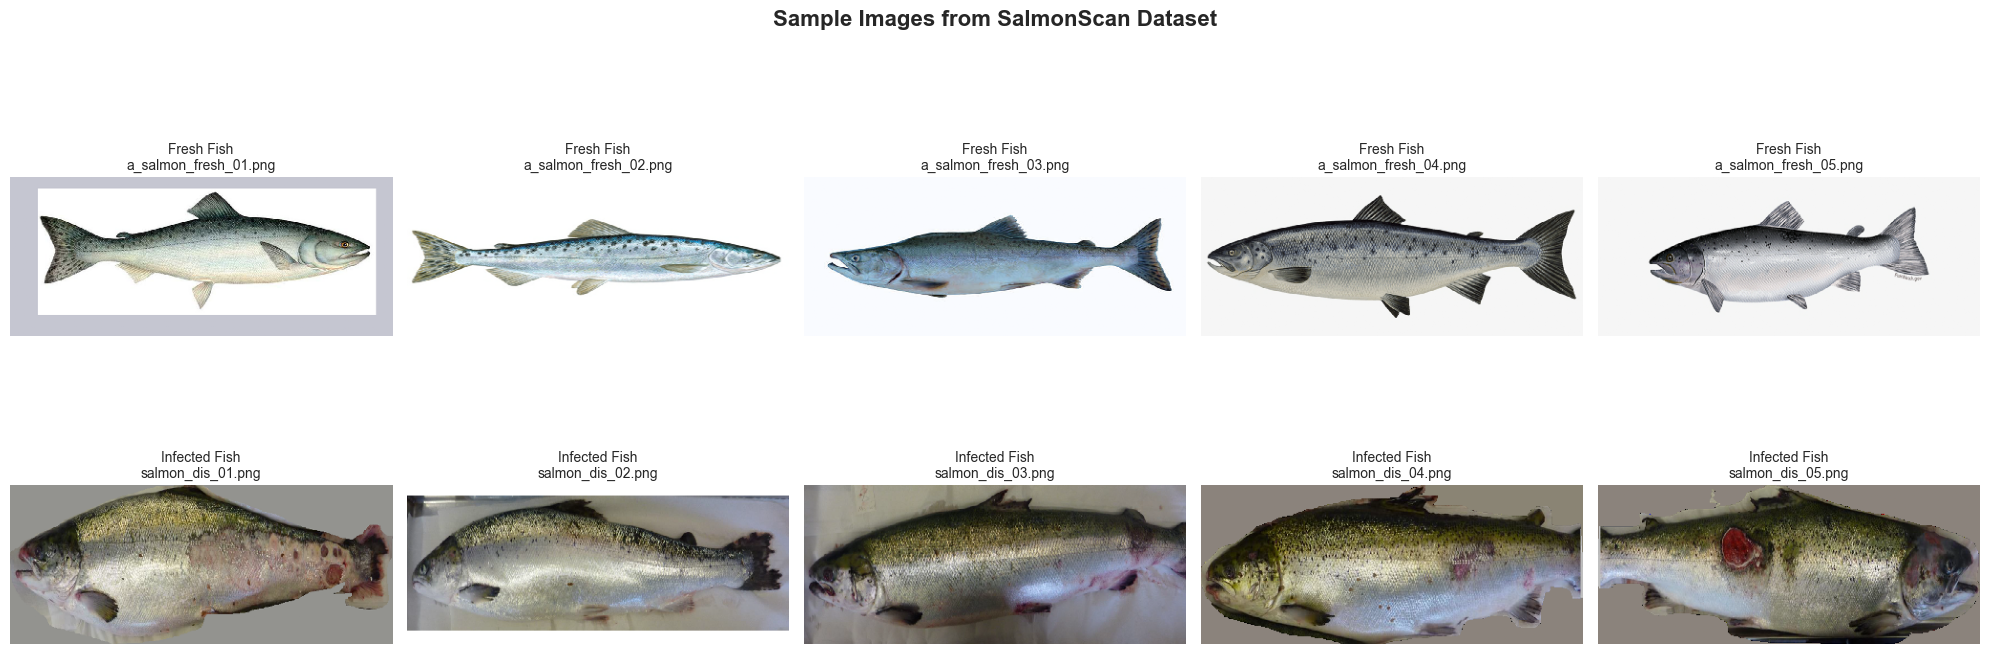

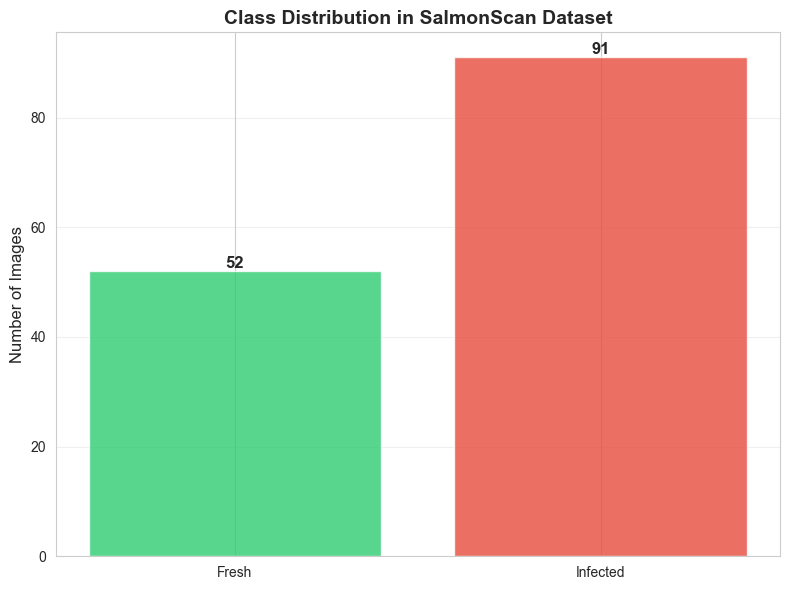

In [4]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample Images from SalmonScan Dataset', fontsize=16, fontweight='bold')

# Show 5 fresh fish
fresh_indices = np.where(y == 0)[0]
for i, ax in enumerate(axes[0]):
    idx = fresh_indices[i]
    ax.imshow(np.clip(X[idx] / 255.0, 0, 1))  # normalize only for display
    ax.set_title(f'Fresh Fish\n{filenames[idx]}', fontsize=10)
    ax.axis('off')

# Show 5 infected fish
infected_indices = np.where(y == 1)[0]
for i, ax in enumerate(axes[1]):
    idx = infected_indices[i]
    ax.imshow(np.clip(X[idx] / 255.0, 0, 1))  # normalize only for display
    ax.set_title(f'Infected Fish\n{filenames[idx]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Class distribution
fig, ax = plt.subplots(figsize=(8, 6))
class_counts = pd.Series(y).value_counts().sort_index()
bars = ax.bar(['Fresh', 'Infected'], class_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution in SalmonScan Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0, height,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.show()

### DMAIC Phase 2: MEASURE
**Step 1-3: Data Collection and Baseline Metrics**
- Split data using Stratified K-Fold Cross-Validation
- Establish baseline performance metrics
- Document data characteristics

In [5]:
# Configure Stratified K-Fold Cross Validation
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

print(f"Configured Stratified K-Fold with {N_FOLDS} folds.")

AUGMENTATIONS_PER_IMAGE = 10  # Keep 10x as requested

Configured Stratified K-Fold with 5 folds.


In [6]:
# GENERATE AUGMENTED DATASET
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create augmentation generator with light geometric transforms (no brightness)
augmentation_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest'
)

def generate_augmented_images(X_class, y_class, n_augmentations, class_name):
    """Generate augmented images for a specific class"""
    
    X_augmented = []
    y_augmented = []
    
    # Fit the generator
    augmentation_datagen.fit(X_class)
    
    n_generated = 0
    batch_size = 32
    target_total = n_augmentations
    
    # Generate augmented images
    for X_batch, y_batch in augmentation_datagen.flow(X_class, y_class, 
                                                       batch_size=batch_size, 
                                                       shuffle=True, 
                                                       seed=SEED):
        for i in range(len(X_batch)):
            if n_generated >= target_total:
                break
            X_augmented.append(X_batch[i])
            y_augmented.append(y_batch[i])
            n_generated += 1
        
        if n_generated >= target_total:
            break
        
    return np.array(X_augmented, dtype=np.float32), np.array(y_augmented)

## 3. Model Architecture Definition
### DMAIC Phase 3: ANALYZE
**Step 4-6: Design Three CNN Architectures + Ensemble**

We will build and compare 3 CNN models with increasing complexity and then an ensemble:
- **Model 1:** 1 Conv layer + 1 MaxPool + 1 Dense (Fully Connected)
- **Model 2:** 2 Conv layers + 2 MaxPool + 1 Dense
- **Model 3:** 3 Conv layers + 3 MaxPool + 1 Dense

In [7]:
def create_cnn_model(num_conv_layers, input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    """Create a CNN model with configurable number of convolutional blocks."""
    model = models.Sequential(name=f'CNN_Model_{num_conv_layers}_Layers')
    
    # First convolutional block
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                           input_shape=input_shape, name='conv1'))
    model.add(layers.BatchNormalization(name='bn1'))  # Added
    model.add(layers.MaxPooling2D((2, 2), name='maxpool1'))
    model.add(layers.Dropout(0.25, name='dropout1'))  # Added
    
    # Additional convolutional blocks based on num_conv_layers
    if num_conv_layers >= 2:
        model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'))
        model.add(layers.BatchNormalization(name='bn2'))  # Added
        model.add(layers.MaxPooling2D((2, 2), name='maxpool2'))
        model.add(layers.Dropout(0.25, name='dropout2'))  # Added
    
    if num_conv_layers >= 3:
        model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3'))
        model.add(layers.BatchNormalization(name='bn3'))  # Added
        model.add(layers.MaxPooling2D((2, 2), name='maxpool3'))
        model.add(layers.Dropout(0.3, name='dropout3'))  # Added
    
    if num_conv_layers >= 4:
        model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4'))
        model.add(layers.BatchNormalization(name='bn4'))  # Added
        model.add(layers.MaxPooling2D((2, 2), name='maxpool4'))
        model.add(layers.Dropout(0.3, name='dropout4'))  # Added
    
    # Flatten and fully connected layers
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(256, activation='relu', name='dense1'))  # Increased from 128
    model.add(layers.BatchNormalization(name='bn_dense'))  # Added
    model.add(layers.Dropout(0.5, name='dropout_dense'))
    model.add(layers.Dense(1, activation='sigmoid', dtype='float32', name='output'))  # dtype for mixed precision
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    )
    
    return model

## 4. Model Training
### DMAIC Phase 3: ANALYZE (Continued)
**Step 7-9: Train Models and Collect Performance Data**

In [8]:
import gc
from tensorflow.keras import backend as K
from sklearn.utils.class_weight import compute_class_weight

# Define callbacks for training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=0
)

callbacks = [early_stopping, reduce_lr]

# Model configurations
model_configs = {
    'Model_1': 1,
    'Model_2': 2,
    'Model_3': 3
}

# Storage for CV predictions (to reconstruct full dataset predictions)
cv_predictions = {name: {'indices': [], 'y_true': [], 'y_pred': [], 'y_prob': []} for name in model_configs}

print("\n" + "="*70)
print(f"Starting Stratified {N_FOLDS}-Fold Cross-Validation...")
print("="*70)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nProcessing Fold {fold+1}/{N_FOLDS}...")
    
    # Split data
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    # Calculate class weights for this fold
    class_weights_fold = compute_class_weight('balanced', classes=np.unique(y_train_fold), y=y_train_fold)
    class_weight_dict = {0: class_weights_fold[0], 1: class_weights_fold[1]}
    
    # Augment Training Data (ONLY training data)
    # Separate by class
    X_train_fresh = X_train_fold[y_train_fold == 0]
    y_train_fresh = y_train_fold[y_train_fold == 0]
    X_train_infected = X_train_fold[y_train_fold == 1]
    y_train_infected = y_train_fold[y_train_fold == 1]
    
    # Calculate targets
    target_fresh = len(X_train_fresh) * AUGMENTATIONS_PER_IMAGE
    target_infected = len(X_train_infected) * AUGMENTATIONS_PER_IMAGE
    
    # Generate augmented
    X_aug_fresh, y_aug_fresh = generate_augmented_images(X_train_fresh, y_train_fresh, target_fresh, "Fresh")
    X_aug_infected, y_aug_infected = generate_augmented_images(X_train_infected, y_train_infected, target_infected, "Infected")
    
    # Combine
    X_train_augmented = np.concatenate([X_aug_fresh, X_aug_infected], axis=0)
    y_train_augmented = np.concatenate([y_aug_fresh, y_aug_infected], axis=0)
    
    # Shuffle
    shuffle_indices = np.random.permutation(len(X_train_augmented))
    X_train_augmented = X_train_augmented[shuffle_indices]
    y_train_augmented = y_train_augmented[shuffle_indices]
    
    # Normalize
    X_train_augmented = X_train_augmented / 255.0
    X_val_scaled = X_val_fold / 255.0
    
    # Train each model configuration
    for model_name, num_layers in model_configs.items():
        print(f"  Training {model_name}...", end="\r")
        
        # Create fresh model
        model = create_cnn_model(num_layers)
        
        # Train
        try:
            model.fit(
                X_train_augmented, y_train_augmented,
                batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(X_val_scaled, y_val_fold),
                callbacks=callbacks,
                class_weight=class_weight_dict,
                verbose=0
            )
        except Exception as e:
             # Retry with smaller batch size if memory error
            K.clear_session()
            gc.collect()
            model = create_cnn_model(num_layers)
            model.fit(
                X_train_augmented, y_train_augmented,
                batch_size=8,
                epochs=EPOCHS,
                validation_data=(X_val_scaled, y_val_fold),
                callbacks=callbacks,
                class_weight=class_weight_dict,
                verbose=0
            )

        # Predict on validation fold
        y_pred_proba = model.predict(X_val_scaled, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        # Store results
        cv_predictions[model_name]['indices'].extend(val_idx)
        cv_predictions[model_name]['y_true'].extend(y_val_fold)
        cv_predictions[model_name]['y_pred'].extend(y_pred)
        cv_predictions[model_name]['y_prob'].extend(y_pred_proba.flatten())
        
        # Clear memory
        K.clear_session()
        gc.collect()
        
    print(f"  Fold {fold+1} completed.        ")

print("\n" + "="*70)
print("Cross-Validation Completed!")
print("="*70)

# Reconstruct full dataset results and create evaluation_results list
evaluation_results = []

# Set X_test and y_test to full dataset for downstream analysis compatibility
X_test = X
y_test = y

for model_name in model_configs:
    data = cv_predictions[model_name]
    
    # Sort by index to match original X, y order
    sorted_indices = np.argsort(data['indices'])
    y_true_sorted = np.array(data['y_true'])[sorted_indices]
    y_pred_sorted = np.array(data['y_pred'])[sorted_indices]
    y_prob_sorted = np.array(data['y_prob'])[sorted_indices]
    
    # Calculate metrics on the full aggregated predictions
    accuracy = accuracy_score(y_true_sorted, y_pred_sorted)
    precision = precision_score(y_true_sorted, y_pred_sorted)
    recall = recall_score(y_true_sorted, y_pred_sorted)
    f1 = f1_score(y_true_sorted, y_pred_sorted)
    auc_roc = roc_auc_score(y_true_sorted, y_prob_sorted)
    
    cm = confusion_matrix(y_true_sorted, y_pred_sorted)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    
    evaluation_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc,
        'Specificity': specificity,
        'True Positives': tp,
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'Predictions': y_pred_sorted,
        'Probabilities': y_prob_sorted,
        'Confusion Matrix': cm
    })

# Create evaluation summary DataFrame
eval_df = pd.DataFrame(evaluation_results)
eval_summary = eval_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Specificity']].copy()

print("\n" + "="*70)
print(f"CV EVALUATION SUMMARY ({N_FOLDS}-Fold Aggregated)")
print("="*70)
print(eval_summary.to_string(index=False))

# Save results for CRISP-DM report
eval_summary.to_csv('model_evaluation_results.csv', index=False)
print("\n✓ Results saved to 'model_evaluation_results.csv'")


Starting Stratified 5-Fold Cross-Validation...

Processing Fold 1/5...
  Fold 1 completed.        

Processing Fold 2/5...
  Fold 2 completed.        

Processing Fold 3/5...
  Fold 3 completed.        

Processing Fold 4/5...
  Fold 4 completed.        

Processing Fold 5/5...
  Fold 5 completed.        

Cross-Validation Completed!

CV EVALUATION SUMMARY (5-Fold Aggregated)
  Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC  Specificity
Model_1  0.972028   0.988764 0.967033  0.977778 0.991547     0.980769
Model_2  0.986014   0.978495 1.000000  0.989130 0.999155     0.961538
Model_3  0.993007   0.989130 1.000000  0.994536 0.999789     0.980769

✓ Results saved to 'model_evaluation_results.csv'


## 5.5 Ensemble Model - Combining All CNNs

### Ensemble Strategy

Combine predictions from all CNN models using **Soft Voting**:

- **Soft Voting**: Average of probabilities from all models (Equal weights)
- **Goal**: Reduce false negatives by leveraging diverse model predictions

In [27]:
# ============================================================================
# MODEL 4: ENSEMBLE - Combining All CNN Predictions
# ============================================================================

print("\n" + "="*70)
print("MODEL 4: ENSEMBLE - COMBINING ALL CNN PREDICTIONS")
print("="*70)

# Collect predictions from all individual CNN models (1-3)
all_predictions = []
all_probabilities = []

for model_name in ['Model_1', 'Model_2', 'Model_3']:
    result = next(r for r in evaluation_results if r['Model'] == model_name)
    all_predictions.append(result['Predictions'])
    all_probabilities.append(result['Probabilities'])

all_predictions = np.array(all_predictions)  # Shape: (n_models, n_test_samples)
all_probabilities = np.array(all_probabilities)  # Shape: (n_models, n_test_samples)

print(f"\nCollected predictions from {all_predictions.shape[0]} models")
print(f"Predictions shape: {all_predictions.shape}")
print(f"Probabilities shape: {all_probabilities.shape}")

# ============================================================================
# ENSEMBLE METHOD: Soft Voting (Average Probabilities)
# ============================================================================
print("\n" + "-"*70)
print("ENSEMBLE METHOD: SOFT VOTING (AVERAGE PROBABILITIES)")
print("-"*70)

# Use equal weights to avoid data leakage (optimizing weights on validation set)
# We simply average the probabilities from all models
recall_weights = np.array([1/3, 1/3, 1/3])

print(f"\nModel Weights (Equal):")
for i, model_name in enumerate(['Model_1', 'Model_2', 'Model_3']):
    print(f"  {model_name}: {recall_weights[i]:.4f}")

# Weighted average of probabilities
ensemble_proba_weighted = np.average(all_probabilities, axis=0, weights=recall_weights)
ensemble_pred_weighted = (ensemble_proba_weighted > 0.5).astype(int)

# Calculate metrics for weighted average
accuracy_weighted = accuracy_score(y_test, ensemble_pred_weighted)
precision_weighted = precision_score(y_test, ensemble_pred_weighted)
recall_weighted = recall_score(y_test, ensemble_pred_weighted)
f1_weighted = f1_score(y_test, ensemble_pred_weighted)
auc_weighted = roc_auc_score(y_test, ensemble_proba_weighted)

print(f"\nSoft Voting Performance:")
print(f"  Accuracy:  {accuracy_weighted:.4f}")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall:    {recall_weighted:.4f}")
print(f"  F1-Score:  {f1_weighted:.4f}")
print(f"  AUC-ROC:   {auc_weighted:.4f}")

# ============================================================================
# Final Ensemble Model
# ============================================================================
print("\n" + "="*70)
print("ENSEMBLE MODEL SELECTION")
print("="*70)

print(f"\n✓ Selected: SOFT VOTING (Recall: {recall_weighted:.4f})")
ensemble_method = "Soft Voting"
ensemble_pred = ensemble_pred_weighted
ensemble_proba = ensemble_proba_weighted

# Calculate final ensemble metrics
accuracy_ensemble = accuracy_score(y_test, ensemble_pred)
precision_ensemble = precision_score(y_test, ensemble_pred)
recall_ensemble = recall_score(y_test, ensemble_pred)
f1_ensemble = f1_score(y_test, ensemble_pred)
auc_ensemble = roc_auc_score(y_test, ensemble_proba)

# Confusion matrix
cm_ensemble = confusion_matrix(y_test, ensemble_pred)
tn, fp, fn, tp = cm_ensemble.ravel()
specificity_ensemble = tn / (tn + fp)

# Add to evaluation results
evaluation_results.append({
    'Model': 'Model_4_Ensemble',
    'Accuracy': accuracy_ensemble,
    'Precision': precision_ensemble,
    'Recall': recall_ensemble,
    'F1-Score': f1_ensemble,
    'AUC-ROC': auc_ensemble,
    'Specificity': specificity_ensemble,
    'True Positives': tp,
    'True Negatives': tn,
    'False Positives': fp,
    'False Negatives': fn,
    'Predictions': ensemble_pred,
    'Probabilities': ensemble_proba,
    'Confusion Matrix': cm_ensemble
})

print(f"\n{'='*70}")
print(f"ENSEMBLE MODEL (Model_4) - {ensemble_method.upper()}")
print(f"{'='*70}")
print(f"\nTest Set Performance:")
print(f"  Accuracy:    {accuracy_ensemble:.4f}")
print(f"  Precision:   {precision_ensemble:.4f}")
print(f"  Recall:      {recall_ensemble:.4f} ⭐ PRIMARY METRIC")
print(f"  F1-Score:    {f1_ensemble:.4f}")
print(f"  AUC-ROC:     {auc_ensemble:.4f}")
print(f"  Specificity: {specificity_ensemble:.4f}")
print(f"\nConfusion Matrix:")
print(f"  TN: {tn:3d}  FP: {fp:3d}")
print(f"  FN: {fn:3d}  TP: {tp:3d}")
print(f"\n🎯 False Negatives Reduced: {fn} missed infections")

# Update eval_summary
eval_df = pd.DataFrame(evaluation_results)
eval_summary = eval_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Specificity']].copy()

print("\n" + "="*70)
print("UPDATED EVALUATION SUMMARY - ALL 5 MODELS")
print("="*70)
print(eval_summary.to_string(index=False))

# Highlight improvement
print("\n" + "="*70)
print("ENSEMBLE IMPROVEMENT ANALYSIS")
print("="*70)
best_individual_recall = max([r['Recall'] for r in evaluation_results if 'Model_' in r['Model'] and 'Ensemble' not in r['Model']])
recall_improvement = recall_ensemble - best_individual_recall
print(f"\nBest Individual Model Recall: {best_individual_recall:.4f}")
print(f"Ensemble Model Recall:        {recall_ensemble:.4f}")
print(f"Improvement:                  {recall_improvement:+.4f} ({recall_improvement/best_individual_recall*100:+.2f}%)")

if recall_improvement > 0:
    print(f"\n✅ Ensemble IMPROVED infected fish detection!")
elif recall_improvement == 0:
    print(f"\n➡️  Ensemble MATCHED best individual model performance")
else:
    print(f"\n⚠️  Ensemble did not improve over best individual model")

# Save updated results
eval_summary.to_csv('model_evaluation_results.csv', index=False)
print(f"\n✓ Updated results saved to 'model_evaluation_results.csv'")


MODEL 4: ENSEMBLE - COMBINING ALL CNN PREDICTIONS

Collected predictions from 3 models
Predictions shape: (3, 143)
Probabilities shape: (3, 143)

----------------------------------------------------------------------
ENSEMBLE METHOD: SOFT VOTING (AVERAGE PROBABILITIES)
----------------------------------------------------------------------

Model Weights (Equal):
  Model_1: 0.3333
  Model_2: 0.3333
  Model_3: 0.3333

Soft Voting Performance:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000

ENSEMBLE MODEL SELECTION

✓ Selected: SOFT VOTING (Recall: 1.0000)

ENSEMBLE MODEL (Model_4) - SOFT VOTING

Test Set Performance:
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000 ⭐ PRIMARY METRIC
  F1-Score:    1.0000
  AUC-ROC:     1.0000
  Specificity: 1.0000

Confusion Matrix:
  TN:  52  FP:   0
  FN:   0  TP:  91

🎯 False Negatives Reduced: 0 missed infections

UPDATED EVALUATION SUMMARY - ALL 5 MODELS
           Model  Accuracy

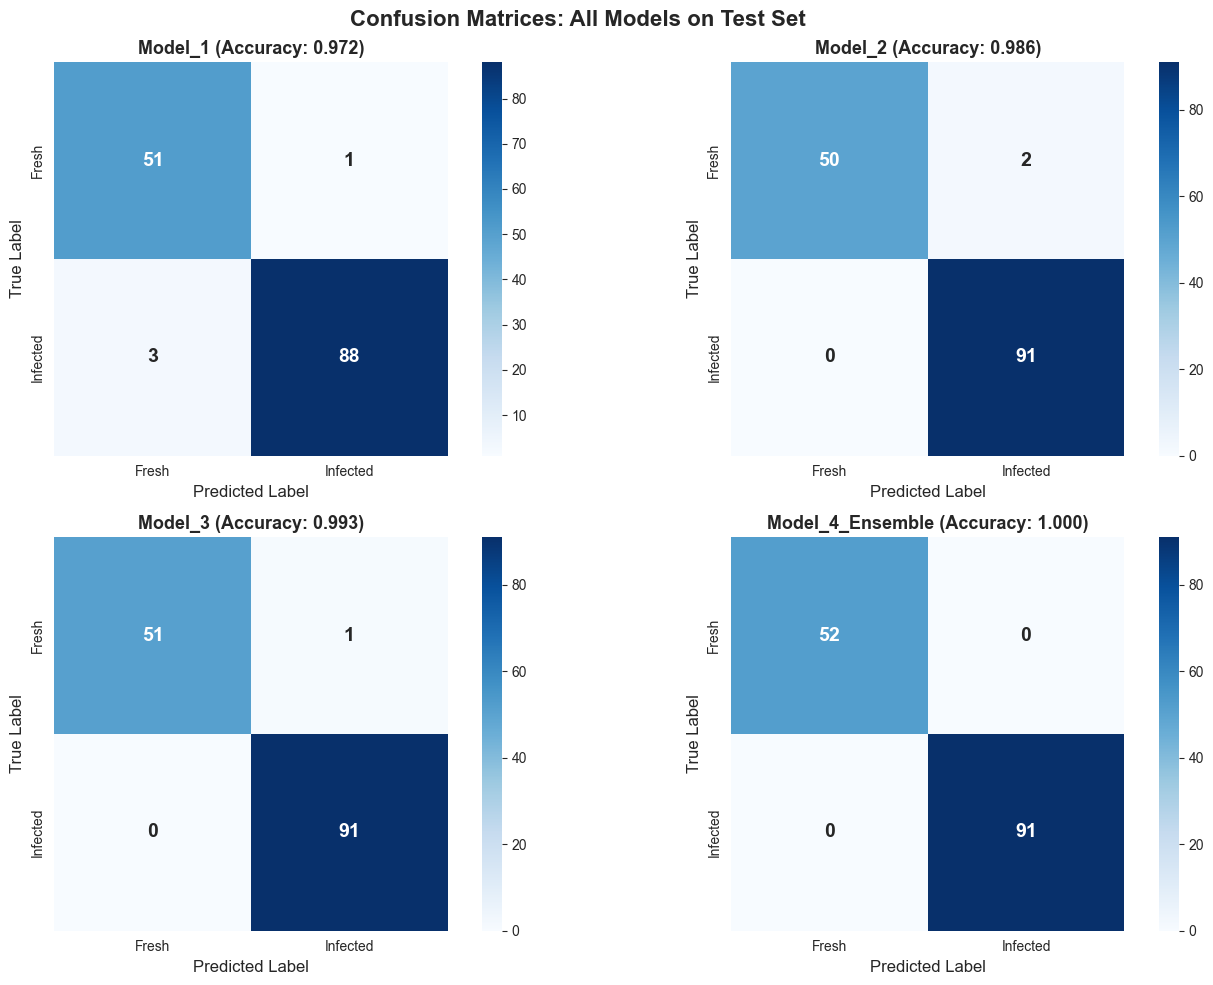

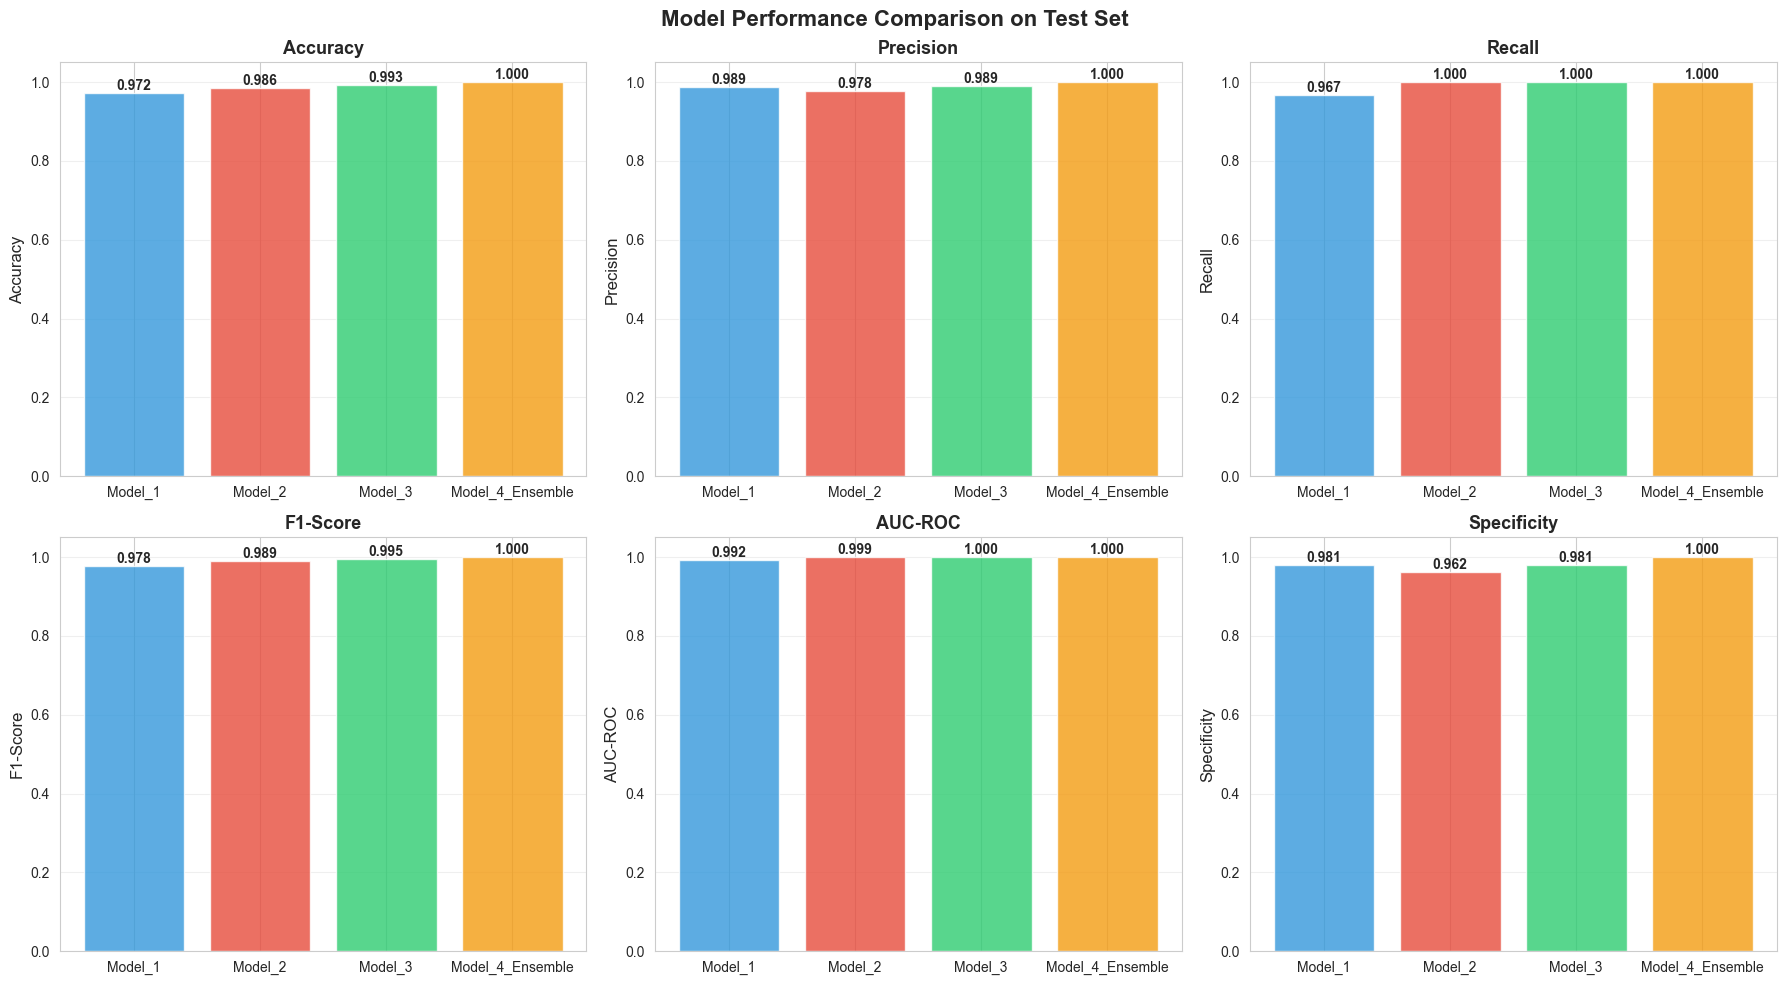

In [28]:
# Visualize confusion matrices for all models
n_models = len(evaluation_results)
n_rows_cm, n_cols_cm = 2, 2  # 4 models -> 2x2 grid
fig, axes = plt.subplots(n_rows_cm, n_cols_cm, figsize=(14, 10))
fig.suptitle('Confusion Matrices: All Models on Test Set', fontsize=16, fontweight='bold')

axes = np.array(axes).reshape(-1)

for idx, result in enumerate(evaluation_results):
    ax = axes[idx]
    cm = result['Confusion Matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                cbar=True, square=True, annot_kws={'size': 14, 'weight': 'bold'})
    
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f"{result['Model']} (Accuracy: {result['Accuracy']:.3f})", 
                 fontsize=13, fontweight='bold')
    ax.set_xticklabels(['Fresh', 'Infected'])
    ax.set_yticklabels(['Fresh', 'Infected'])

# Hide any unused subplots (should not happen with 4 models, but safe)
for j in range(len(evaluation_results), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Compare metrics visually
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 6 metrics -> fixed 2x3 grid
fig.suptitle('Model Performance Comparison on Test Set', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Specificity']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    values = eval_summary[metric].values
    bars = ax.bar(eval_summary['Model'], values, color=colors, alpha=0.8)
    
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=0)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',

                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

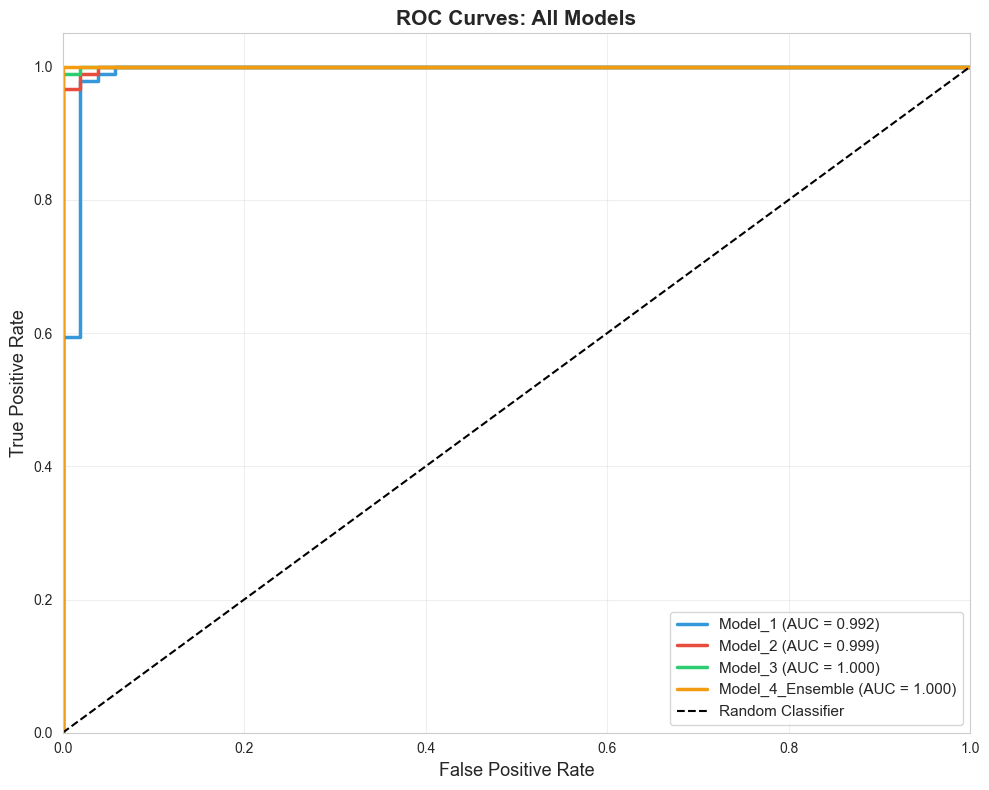

In [29]:
# Plot ROC curves for all models
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

roc_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, result in enumerate(evaluation_results):
    fpr, tpr, _ = roc_curve(y_test, result['Probabilities'])
    auc = result['AUC-ROC']
    ax.plot(fpr, tpr, color=roc_colors[idx], linewidth=2.5, 
            label=f"{result['Model']} (AUC = {auc:.3f})")

# Plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves: All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

## 6. Six Sigma DMAIC Analysis
### DMAIC Phase 4: IMPROVE
**Step 13: Calculate Six Sigma Metrics and Process Capability**

Six Sigma methodology uses statistical analysis to evaluate process quality:
- **Defects Per Million Opportunities (DPMO)**
- **Sigma Level**: Measures process capability (higher is better)
- **Process Capability Indices (Cp, Cpk)**

In [30]:
# Calculate Six Sigma metrics for each model
from scipy import stats

def calculate_sigma_level(accuracy):
    """
    Calculate Sigma level from accuracy
    Sigma Level is related to DPMO (Defects Per Million Opportunities)
    """
    defect_rate = 1 - accuracy
    dpmo = defect_rate * 1_000_000
    
    # Calculate Z-score (sigma level)
    # Using standard normal distribution
    if defect_rate >= 0.5:
        sigma_level = 0
    elif defect_rate <= 0.00000001:
        sigma_level = 6.0
    else:
        # Z-score from defect rate
        sigma_level = stats.norm.ppf(1 - defect_rate)
    
    return sigma_level, dpmo

def calculate_process_capability(y_true, y_pred):
    """
    Calculate process capability indices Cp and Cpk
    These measure how well the process fits within specification limits
    """
    # Use accuracy as process metric
    accuracy = accuracy_score(y_true, y_pred)
    
    # For classification: target = 1.0 (perfect accuracy)
    # Specification limits: LSL = 0, USL = 1.0
    USL = 1.0
    LSL = 0.0
    target = 1.0
    
    # Standard deviation of prediction errors
    errors = (y_true != y_pred).astype(float)
    std_errors = np.std(errors)
    
    if std_errors == 0:
        Cp = Cpk = float('inf')
    else:
        # Cp: Process capability (assumes process is centered)
        Cp = (USL - LSL) / (6 * std_errors)
        
        # Cpk: Process capability accounting for centering
        mean_process = accuracy
        Cpk = min((USL - mean_process) / (3 * std_errors), 
                  (mean_process - LSL) / (3 * std_errors))
    
    return Cp, Cpk

# Calculate Six Sigma metrics for all models
# FOCUS ON INFECTED FISH DETECTION (Recall) as primary quality metric
six_sigma_results = []

print("\n" + "="*80)
print("⚠️  SIX SIGMA ANALYSIS - INFECTED FISH DETECTION FOCUS")
print("="*80)
print("Primary Metric: RECALL (Sensitivity for Infected Class)")
print("Rationale: False Negatives (missed infections) are catastrophic")
print("="*80 + "\n")

for result in evaluation_results:
    model_name = result['Model']
    accuracy = result['Accuracy']
    recall = result['Recall']  # Primary metric for infected detection
    y_pred = result['Predictions']
    
    # Calculate Sigma metrics based on RECALL (infected fish detection rate)
    sigma_level_recall, dpmo_recall = calculate_sigma_level(recall)
    
    # Also calculate overall sigma for comparison
    sigma_level_overall, dpmo_overall = calculate_sigma_level(accuracy)
    
    # Calculate process capability
    Cp, Cpk = calculate_process_capability(y_test, y_pred)
    
    # Get confusion matrix values
    cm = result['Confusion Matrix']
    tn, fp, fn, tp = cm.ravel()
    
    six_sigma_results.append({
        'Model': model_name,
        'Recall (Infected)': recall,  # PRIMARY METRIC
        'Accuracy (Overall)': accuracy,
        'Infected DPMO': dpmo_recall,  # Defects in infected detection
        'Overall DPMO': dpmo_overall,
        'Infected Sigma': sigma_level_recall,  # PRIMARY SIGMA
        'Overall Sigma': sigma_level_overall,
        'Cp': Cp,
        'Cpk': Cpk,
        'False Negatives': fn,  # CRITICAL DEFECT
        'False Positives': fp,
        'Total Infected': fn + tp,
        'Total Opportunities': len(y_test)
    })

# Create Six Sigma summary DataFrame
six_sigma_df = pd.DataFrame(six_sigma_results)

print("="*100)
print("📊 SIX SIGMA QUALITY METRICS - INFECTED FISH DETECTION FOCUS")
print("="*100)
print(six_sigma_df[['Model', 'Recall (Infected)', 'Infected DPMO', 'Infected Sigma', 
                     'False Negatives', 'Accuracy (Overall)', 'Overall Sigma']].to_string(index=False))
print("\n" + "="*100)
print("🔴 CRITICAL: 'Infected Sigma' is the primary quality metric")
print("   False Negatives (missed infections) cause disease outbreaks")
print("="*100)

# Interpretation guide
print("\nSIX SIGMA INTERPRETATION (for Infected Fish Detection):")
print("-" * 100)
print("Sigma Level → Infected Detection Rate → Business Impact:")
print("  1σ = 691,462 DPMO (31% detection) → ❌ UNACCEPTABLE - Most infections missed")
print("  2σ = 308,538 DPMO (69% detection) → ⚠️  POOR - High disease spread risk")
print("  3σ =  66,807 DPMO (93% detection) → ⚡ ACCEPTABLE - Minimum for deployment")
print("  4σ =   6,210 DPMO (99.4% detection) → ✅ GOOD - Suitable for production")
print("  5σ =     233 DPMO (99.977% detection) → 🌟 EXCELLENT - Industry leading")
print("  6σ =       3.4 DPMO (99.99966% detection) → 🏆 WORLD CLASS - Near perfect")
print("\nProcess Capability (Cpk) interpretation:")
print("  Cpk < 1.0:  Process not capable (poor)")
print("  Cpk = 1.0:  Process minimally capable")
print("  Cpk = 1.33: Process capable (acceptable)")
print("  Cpk > 1.67: Process highly capable (good)")
print("  Cpk > 2.0:  Process excellent")

# Save for CRISP-DM report
six_sigma_df.to_csv('six_sigma_analysis.csv', index=False)
print("\n✓ Six Sigma results saved to 'six_sigma_analysis.csv'")






⚠️  SIX SIGMA ANALYSIS - INFECTED FISH DETECTION FOCUS
Primary Metric: RECALL (Sensitivity for Infected Class)
Rationale: False Negatives (missed infections) are catastrophic

📊 SIX SIGMA QUALITY METRICS - INFECTED FISH DETECTION FOCUS
           Model  Recall (Infected)  Infected DPMO  Infected Sigma  False Negatives  Accuracy (Overall)  Overall Sigma
         Model_1           0.967033   32967.032967        1.838872                3            0.972028       1.911471
         Model_2           1.000000       0.000000        6.000000                0            0.986014       2.197678
         Model_3           1.000000       0.000000        6.000000                0            0.993007       2.457622
Model_4_Ensemble           1.000000       0.000000        6.000000                0            1.000000       6.000000

🔴 CRITICAL: 'Infected Sigma' is the primary quality metric
   False Negatives (missed infections) cause disease outbreaks

SIX SIGMA INTERPRETATION (for Infected Fish 

## 6.1. Advanced Model Analysis
### Additional analyses for comprehensive CRISP-DM report:
- Learning curve analysis (diagnose over/underfitting)
- Error case analysis (which images are difficult?)
- Confidence distribution analysis
- Per-class performance breakdown

In [31]:
# ============================================================================
# ERROR ANALYSIS - Which images are most difficult?
# ============================================================================

def analyze_error_cases(X_test, y_test, y_pred, y_proba, top_n=10):
    """Find the most confidently wrong predictions"""
    
    # Find incorrect predictions
    incorrect_mask = (y_pred != y_test)
    incorrect_indices = np.where(incorrect_mask)[0]
    
    # Get confidence for wrong predictions
    wrong_confidences = []
    for idx in incorrect_indices:
        pred_class = y_pred[idx]
        confidence = y_proba[idx] if pred_class == 1 else (1 - y_proba[idx])
        wrong_confidences.append((idx, confidence, y_test[idx], pred_class))
    
    # Sort by confidence (most confident mistakes first)
    wrong_confidences.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\n{'='*80}")
    print(f"ERROR ANALYSIS: Top {top_n} Most Confident Mistakes")
    print(f"{'='*80}")
    
    for rank, (idx, conf, true_label, pred_label) in enumerate(wrong_confidences[:top_n], 1):
        true_name = 'Fresh' if true_label == 0 else 'Infected'
        pred_name = 'Fresh' if pred_label == 0 else 'Infected'
        print(f"{rank:2d}. Test image {idx:3d}: True={true_name:8s} | "
              f"Predicted={pred_name:8s} | Confidence={conf:.2%}")
    
    return wrong_confidences

# Analyze errors for each model
print("="*80)
print("ERROR ANALYSIS - ALL MODELS")
print("="*80)

error_analysis_results = {}
for result in evaluation_results:
    model_name = result['Model']
    y_pred = result['Predictions']
    y_proba = result['Probabilities']
    
    print(f"\n{model_name}:")
    wrong_confidences = analyze_error_cases(X_test, y_test, y_pred, y_proba, top_n=5)
    error_analysis_results[model_name] = wrong_confidences

# Find images that multiple models misclassify
print("\n" + "="*80)
print("CONSENSUS DIFFICULT CASES (Misclassified by Multiple Models)")
print("="*80)

misclassification_count = np.zeros(len(X_test))
for result in evaluation_results:
    y_pred = result['Predictions']
    misclassified = (y_pred != y_test)
    misclassification_count += misclassified

# Find images misclassified by 3+ models
difficult_cases = np.where(misclassification_count >= 3)[0]
n_models = len(evaluation_results)

print(f"\nFound {len(difficult_cases)} images misclassified by 3+ models:")
for idx in difficult_cases[:10]:  # Show first 10
    true_name = 'Fresh' if y_test[idx] == 0 else 'Infected'
    times_wrong = int(misclassification_count[idx])
    print(f"  Test image {idx:3d}: True={true_name:8s} | Misclassified by {times_wrong}/{n_models} models")





ERROR ANALYSIS - ALL MODELS

Model_1:

ERROR ANALYSIS: Top 5 Most Confident Mistakes
 1. Test image  25: True=Fresh    | Predicted=Infected | Confidence=99.67%
 2. Test image 124: True=Infected | Predicted=Fresh    | Confidence=89.67%
 3. Test image 105: True=Infected | Predicted=Fresh    | Confidence=60.67%
 4. Test image 123: True=Infected | Predicted=Fresh    | Confidence=52.40%

Model_2:

ERROR ANALYSIS: Top 5 Most Confident Mistakes
 1. Test image  28: True=Fresh    | Predicted=Infected | Confidence=81.08%
 2. Test image   2: True=Fresh    | Predicted=Infected | Confidence=58.55%

Model_3:

ERROR ANALYSIS: Top 5 Most Confident Mistakes
 1. Test image  27: True=Fresh    | Predicted=Infected | Confidence=72.57%

Model_4_Ensemble:

ERROR ANALYSIS: Top 5 Most Confident Mistakes

CONSENSUS DIFFICULT CASES (Misclassified by Multiple Models)

Found 0 images misclassified by 3+ models:


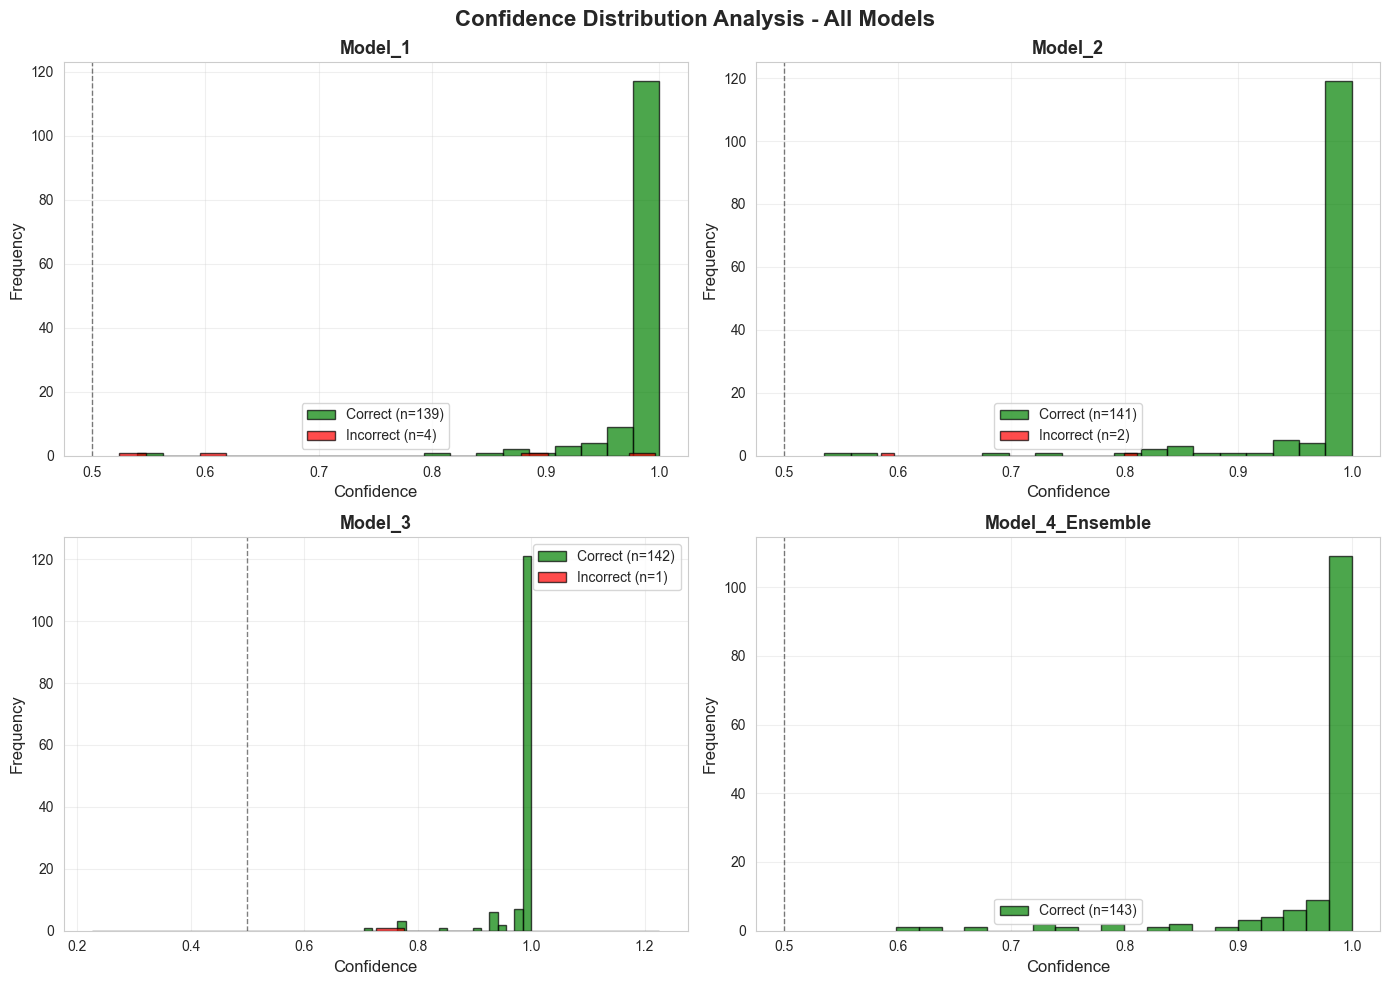

In [32]:
# ============================================================================
# CONFIDENCE DISTRIBUTION ANALYSIS
# ============================================================================

def analyze_confidence_distribution(y_test, y_pred, y_proba):
    """Analyze how confident the model is in its predictions"""
    
    # Calculate confidence for each prediction
    confidences = []
    for i in range(len(y_pred)):
        conf = y_proba[i] if y_pred[i] == 1 else (1 - y_proba[i])
        confidences.append(conf)
    
    confidences = np.array(confidences)
    correct_mask = (y_pred == y_test)
    
    correct_confidences = confidences[correct_mask]
    incorrect_confidences = confidences[~correct_mask]
    
    print(f"\n{'='*80}")
    print(f"CONFIDENCE DISTRIBUTION ANALYSIS")
    print(f"{'='*80}")
    print(f"\nCorrect Predictions (n={len(correct_confidences)}):")
    print(f"  Mean confidence:   {np.mean(correct_confidences):.4f}")
    print(f"  Median confidence: {np.median(correct_confidences):.4f}")
    print(f"  Min confidence:    {np.min(correct_confidences):.4f}")
    
    if len(incorrect_confidences) > 0:
        print(f"\nIncorrect Predictions (n={len(incorrect_confidences)}):")
        print(f"  Mean confidence:   {np.mean(incorrect_confidences):.4f}")
        print(f"  Median confidence: {np.median(incorrect_confidences):.4f}")
        print(f"  Max confidence:    {np.max(incorrect_confidences):.4f}")
    
    return correct_confidences, incorrect_confidences

# Analyze confidence for all models
n_models_conf = len(evaluation_results)
n_rows_conf, n_cols_conf = 2, 2  # 4 models -> 2x2 grid
fig, axes = plt.subplots(n_rows_conf, n_cols_conf, figsize=(14, 10))
fig.suptitle('Confidence Distribution Analysis - All Models', fontsize=16, fontweight='bold')

axes = np.array(axes).reshape(-1)

for idx, result in enumerate(evaluation_results):
    ax = axes[idx]
    model_name = result['Model']
    y_pred = result['Predictions']
    y_proba = result['Probabilities']
    
    # Calculate confidences
    confidences = []
    for i in range(len(y_pred)):
        conf = y_proba[i] if y_pred[i] == 1 else (1 - y_proba[i])
        confidences.append(conf)
    
    confidences = np.array(confidences)
    correct_mask = (y_pred == y_test)
    
    correct_confidences = confidences[correct_mask]
    incorrect_confidences = confidences[~correct_mask]
    
    # Plot histogram
    ax.hist(correct_confidences, bins=20, alpha=0.7, color='green', 
            edgecolor='black', label=f'Correct (n={len(correct_confidences)})')
    if len(incorrect_confidences) > 0:
        ax.hist(incorrect_confidences, bins=20, alpha=0.7, color='red', 
                edgecolor='black', label=f'Incorrect (n={len(incorrect_confidences)})')
    
    ax.set_xlabel('Confidence', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Hide any unused subplots (should not happen with 4 models, but safe)
for j in range(len(evaluation_results), len(axes)):
    axes[j].axis('off')


plt.tight_layout()# Note: Detailed analysis for the best model will be shown after model selection

plt.show()

PER-CLASS PERFORMANCE - ALL MODELS

Model_1:

PER-CLASS PERFORMANCE ANALYSIS

Fresh Fish (Class 0):
  Samples:              52
  Correctly classified: 51
  Accuracy:             0.9808 (98.08%)
  Avg confidence:       0.9852

Infected Fish (Class 1):
  Samples:              91
  Correctly classified: 88
  Accuracy:             0.9670 (96.70%)
  Avg confidence:       0.9724

Balanced Accuracy: 0.9739

Model_2:

PER-CLASS PERFORMANCE ANALYSIS

Fresh Fish (Class 0):
  Samples:              52
  Correctly classified: 50
  Accuracy:             0.9615 (96.15%)
  Avg confidence:       0.9584

Infected Fish (Class 1):
  Samples:              91
  Correctly classified: 91
  Accuracy:             1.0000 (100.00%)
  Avg confidence:       0.9794

Balanced Accuracy: 0.9808

Model_3:

PER-CLASS PERFORMANCE ANALYSIS

Fresh Fish (Class 0):
  Samples:              52
  Correctly classified: 51
  Accuracy:             0.9808 (98.08%)
  Avg confidence:       0.9755

Infected Fish (Class 1):
  Samples:  

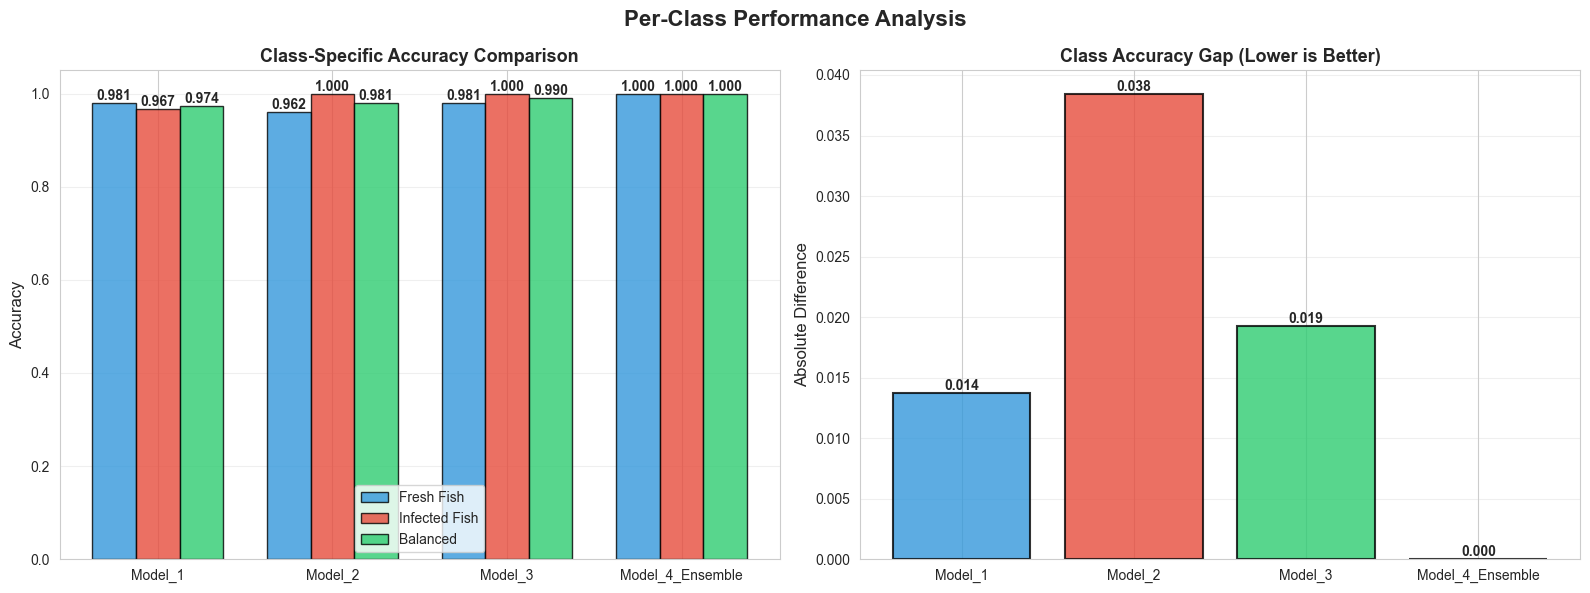


PER-CLASS PERFORMANCE SUMMARY
           Model  Fresh Accuracy  Infected Accuracy  Balanced Accuracy  Difference
         Model_1        0.980769           0.967033           0.973901    0.013736
         Model_2        0.961538           1.000000           0.980769    0.038462
         Model_3        0.980769           1.000000           0.990385    0.019231
Model_4_Ensemble        1.000000           1.000000           1.000000    0.000000


In [33]:
# ============================================================================
# PER-CLASS PERFORMANCE ANALYSIS
# ============================================================================

def analyze_per_class_performance(y_test, y_pred, y_proba):
    """Detailed breakdown by class"""
    
    # Fresh fish (class 0)
    fresh_mask = (y_test == 0)
    fresh_correct = np.sum((y_test[fresh_mask] == y_pred[fresh_mask]))
    fresh_total = np.sum(fresh_mask)
    fresh_accuracy = fresh_correct / fresh_total if fresh_total > 0 else 0
    
    # Infected fish (class 1)
    infected_mask = (y_test == 1)
    infected_correct = np.sum((y_test[infected_mask] == y_pred[infected_mask]))
    infected_total = np.sum(infected_mask)
    infected_accuracy = infected_correct / infected_total if infected_total > 0 else 0
    
    # Average confidence per class
    fresh_confidences = []
    infected_confidences = []
    
    for i in range(len(y_test)):
        conf = y_proba[i] if y_pred[i] == 1 else (1 - y_proba[i])
        if y_test[i] == 0:
            fresh_confidences.append(conf)
        else:
            infected_confidences.append(conf)
    
    print(f"\n{'='*80}")
    print(f"PER-CLASS PERFORMANCE ANALYSIS")
    print(f"{'='*80}")
    print(f"\nFresh Fish (Class 0):")
    print(f"  Samples:              {fresh_total}")
    print(f"  Correctly classified: {fresh_correct}")
    print(f"  Accuracy:             {fresh_accuracy:.4f} ({fresh_accuracy*100:.2f}%)")
    print(f"  Avg confidence:       {np.mean(fresh_confidences):.4f}")
    
    print(f"\nInfected Fish (Class 1):")
    print(f"  Samples:              {infected_total}")
    print(f"  Correctly classified: {infected_correct}")
    print(f"  Accuracy:             {infected_accuracy:.4f} ({infected_accuracy*100:.2f}%)")
    print(f"  Avg confidence:       {np.mean(infected_confidences):.4f}")
    
    balanced_acc = (fresh_accuracy + infected_accuracy) / 2
    print(f"\nBalanced Accuracy: {balanced_acc:.4f}")
    
    return fresh_accuracy, infected_accuracy, balanced_acc

# Analyze per-class performance for all models
print("="*80)
print("PER-CLASS PERFORMANCE - ALL MODELS")
print("="*80)

per_class_results = []
for result in evaluation_results:
    model_name = result['Model']
    y_pred = result['Predictions']
    y_proba = result['Probabilities']
    
    print(f"\n{model_name}:")
    fresh_acc, infected_acc, balanced_acc = analyze_per_class_performance(y_test, y_pred, y_proba)
    
    per_class_results.append({
        'Model': model_name,
        'Fresh Accuracy': fresh_acc,
        'Infected Accuracy': infected_acc,
        'Balanced Accuracy': balanced_acc
    })

# Visualize per-class performance
per_class_df = pd.DataFrame(per_class_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Per-Class Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1: Class-specific accuracies
ax = axes[0]
x = np.arange(len(per_class_df))
width = 0.25

bars1 = ax.bar(x - width, per_class_df['Fresh Accuracy'], width, 
               label='Fresh Fish', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x, per_class_df['Infected Accuracy'], width, 
               label='Infected Fish', color='#e74c3c', alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, per_class_df['Balanced Accuracy'], width, 
               label='Balanced', color='#2ecc71', alpha=0.8, edgecolor='black')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Class-Specific Accuracy Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(per_class_df['Model'], rotation=0)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',

                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Difference between classes
ax = axes[1]
per_class_df['Difference'] = abs(per_class_df['Fresh Accuracy'] - per_class_df['Infected Accuracy'])
colors_5models = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax.bar(per_class_df['Model'], per_class_df['Difference'], 
              color=colors_5models, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Absolute Difference', fontsize=12)
ax.set_title('Class Accuracy Gap (Lower is Better)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("PER-CLASS PERFORMANCE SUMMARY")
print("="*100)
print(per_class_df.to_string(index=False))

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_79084\2857342972.py:87: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_79084\2857342972.py:87: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_79084\2857342972.py:87: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Gabriel\Documents\Skole\IND310\Salmon-Disease-Detection-1\.conda\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Gabriel\Documents\Skole\IND310\Salmon-Disease-Detection-1\.conda\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(byte

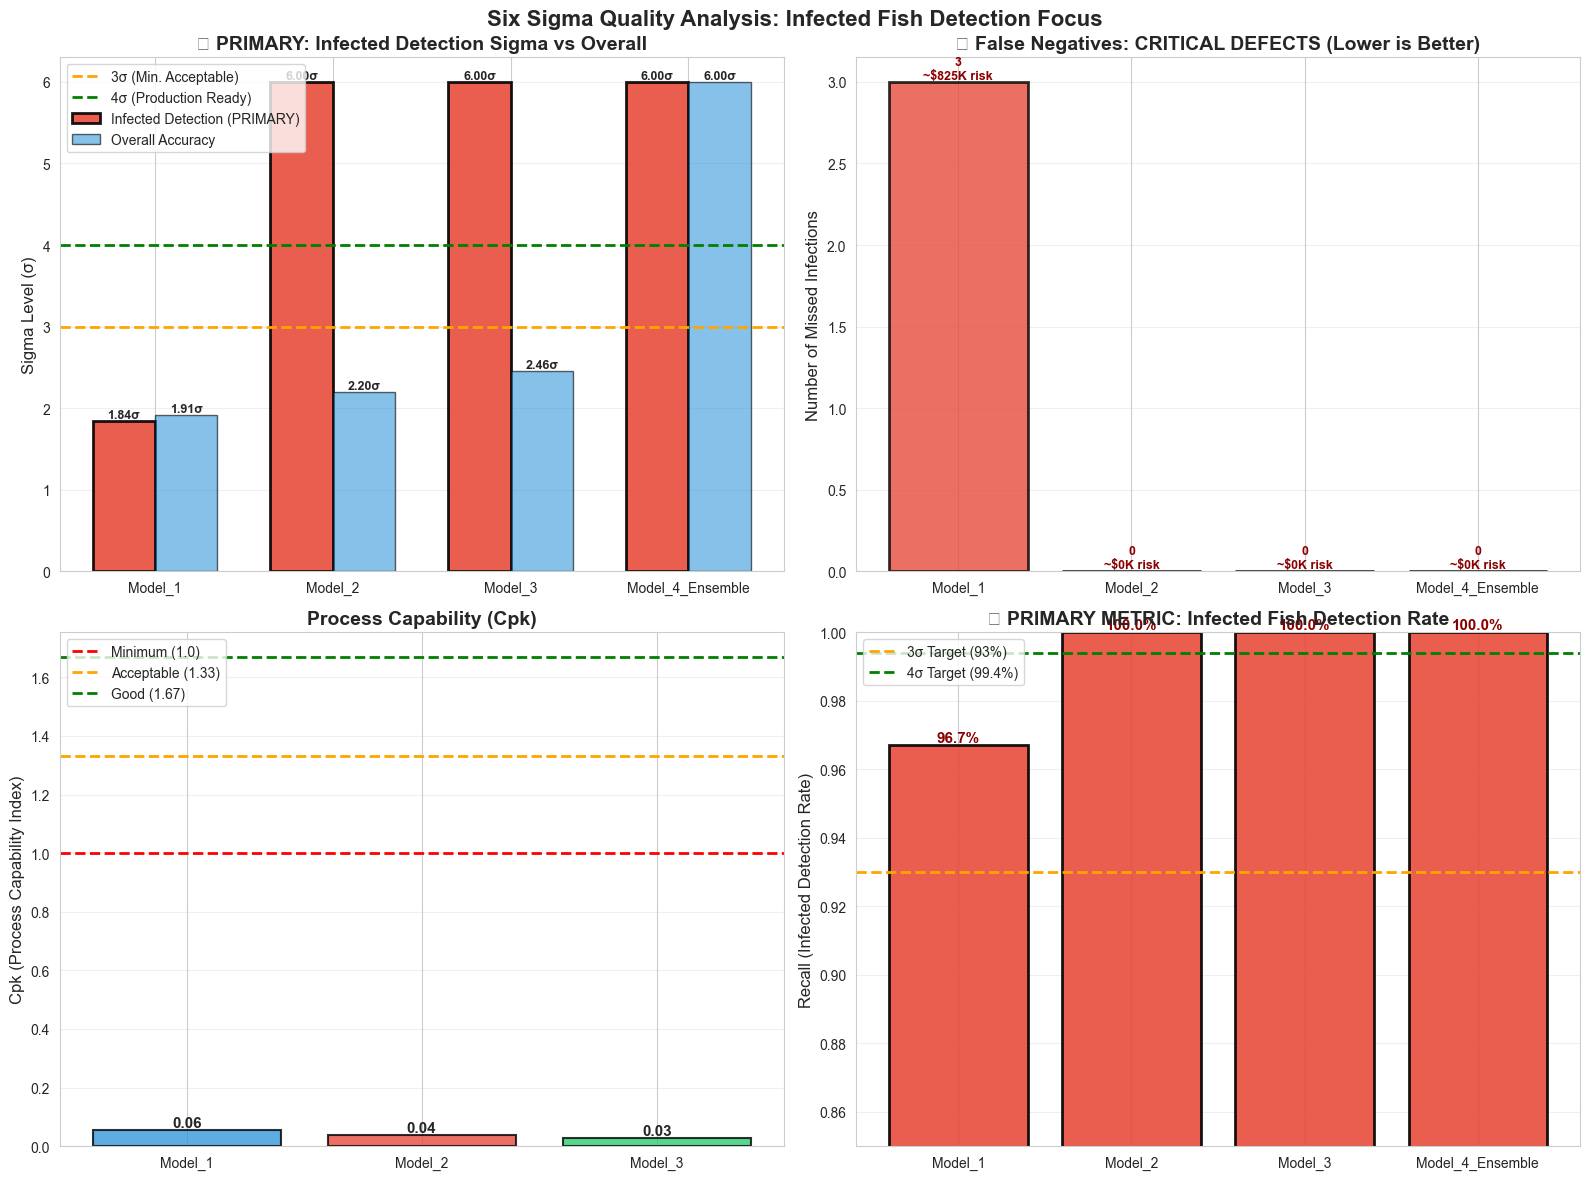

In [34]:
# Visualize Six Sigma metrics - Focus on Infected Detection
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Six Sigma Quality Analysis: Infected Fish Detection Focus', fontsize=16, fontweight='bold')

# Update colors list for 5 models
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Plot 1: Infected Sigma Level vs Overall Sigma (COMPARISON)
ax = axes[0, 0]
x = np.arange(len(six_sigma_df))
width = 0.35

bars1 = ax.bar(x - width/2, six_sigma_df['Infected Sigma'], width,
              label='Infected Detection (PRIMARY)', color='#e74c3c', alpha=0.9, edgecolor='black', linewidth=2)
bars2 = ax.bar(x + width/2, six_sigma_df['Overall Sigma'], width,
              label='Overall Accuracy', color='#3498db', alpha=0.6, edgecolor='black', linewidth=1)

ax.set_ylabel('Sigma Level (σ)', fontsize=12)
ax.set_title('🔴 PRIMARY: Infected Detection Sigma vs Overall', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(six_sigma_df['Model'])
ax.axhline(y=3, color='orange', linestyle='--', linewidth=2, label='3σ (Min. Acceptable)')
ax.axhline(y=4, color='green', linestyle='--', linewidth=2, label='4σ (Production Ready)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}σ', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

# Plot 2: False Negatives (CRITICAL DEFECTS)
ax = axes[0, 1]
bars = ax.bar(six_sigma_df['Model'], six_sigma_df['False Negatives'], 
              color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Missed Infections', fontsize=12)
ax.set_title('🚨 False Negatives: CRITICAL DEFECTS (Lower is Better)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Calculate cost implications
avg_outbreak_cost = 275000  # Average of $50k-$500k
for i, bar in enumerate(bars):
    height = bar.get_height()
    potential_cost = height * avg_outbreak_cost
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n~${potential_cost/1000:.0f}K risk', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold', color='darkred')

# Plot 3: Process Capability (Cpk)
ax = axes[1, 0]
bars = ax.bar(six_sigma_df['Model'], six_sigma_df['Cpk'], 
              color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Cpk (Process Capability Index)', fontsize=12)
ax.set_title('Process Capability (Cpk)', fontsize=14, fontweight='bold')
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Minimum (1.0)')
ax.axhline(y=1.33, color='orange', linestyle='--', linewidth=2, label='Acceptable (1.33)')
ax.axhline(y=1.67, color='green', linestyle='--', linewidth=2, label='Good (1.67)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

# Plot 4: Recall (Infected Detection) - THE PRIMARY METRIC
ax = axes[1, 1]
bars = ax.bar(six_sigma_df['Model'], six_sigma_df['Recall (Infected)'], 
              color='#e74c3c', alpha=0.9, edgecolor='black', linewidth=2)
ax.set_ylabel('Recall (Infected Detection Rate)', fontsize=12)
ax.set_title('⭐ PRIMARY METRIC: Infected Fish Detection Rate', fontsize=14, fontweight='bold')
ax.axhline(y=0.93, color='orange', linestyle='--', linewidth=2, label='3σ Target (93%)')
ax.axhline(y=0.994, color='green', linestyle='--', linewidth=2, label='4σ Target (99.4%)')
ax.set_ylim([0.85, 1.0])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height*100:.1f}%', ha='center', va='bottom', 
            fontsize=11, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

### Statistical Analysis and Control Charts
**Step 14: Create Control Charts and Statistical Process Control**

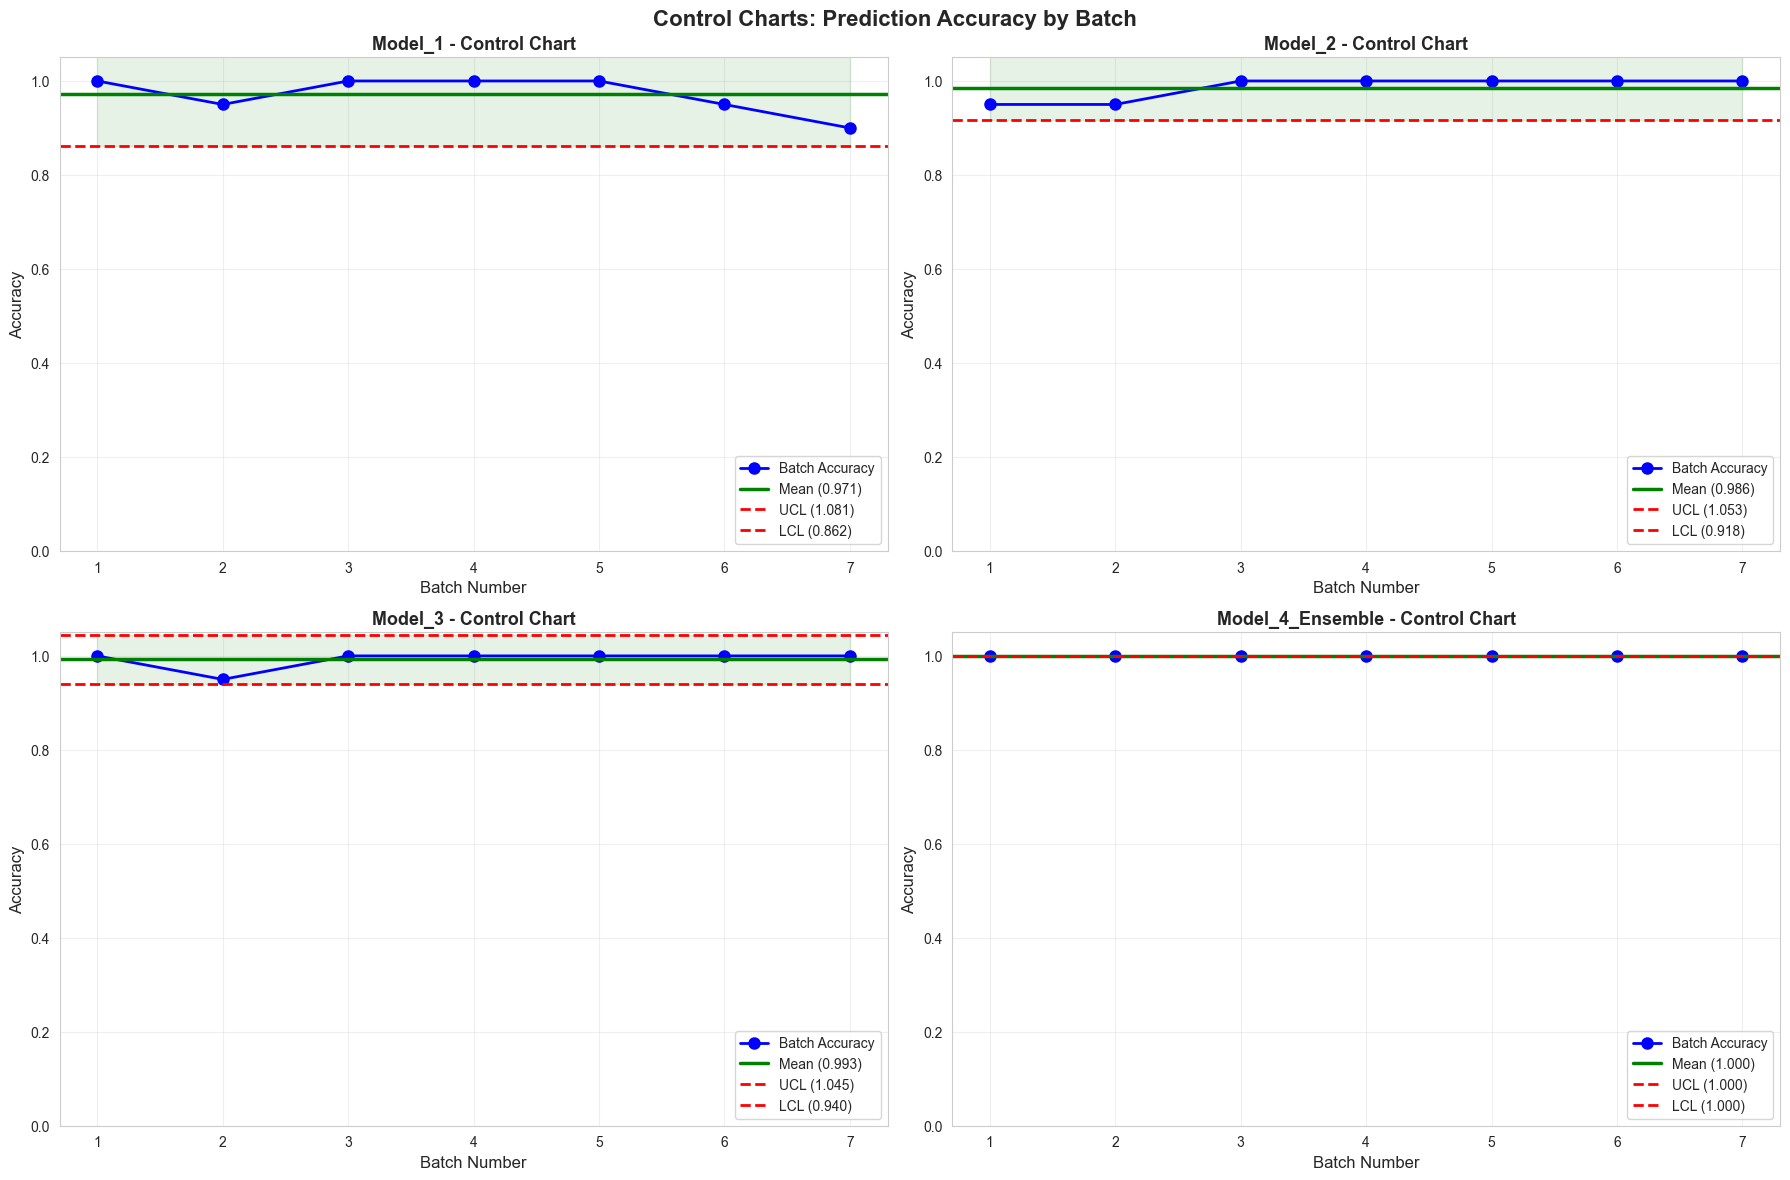

PROCESS STABILITY ANALYSIS

Model_1:
  Mean Accuracy:        0.9714
  Std Deviation:        0.0364
  Coefficient of Var:   3.75%
  UCL:                  1.0807
  LCL:                  0.8622
  Out-of-Control Points: 0/7
  Process Stable:       Yes

Model_2:
  Mean Accuracy:        0.9857
  Std Deviation:        0.0226
  Coefficient of Var:   2.29%
  UCL:                  1.0535
  LCL:                  0.9180
  Out-of-Control Points: 0/7
  Process Stable:       Yes

Model_3:
  Mean Accuracy:        0.9929
  Std Deviation:        0.0175
  Coefficient of Var:   1.76%
  UCL:                  1.0453
  LCL:                  0.9404
  Out-of-Control Points: 0/7
  Process Stable:       Yes

Model_4_Ensemble:
  Mean Accuracy:        1.0000
  Std Deviation:        0.0000
  Coefficient of Var:   0.00%
  UCL:                  1.0000
  LCL:                  1.0000
  Out-of-Control Points: 0/7
  Process Stable:       Yes


In [35]:
# Control Chart Analysis
# Monitor prediction accuracy across batches to ensure process stability

def create_control_chart_data(y_true, y_pred, batch_size=20):
    """Create control chart data by splitting predictions into batches"""
    n_samples = len(y_true)
    n_batches = n_samples // batch_size
    
    batch_accuracies = []
    batch_numbers = []
    
    for i in range(n_batches):
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        
        batch_y_true = y_true[start_idx:end_idx]
        batch_y_pred = y_pred[start_idx:end_idx]
        
        batch_acc = accuracy_score(batch_y_true, batch_y_pred)
        batch_accuracies.append(batch_acc)
        batch_numbers.append(i + 1)
    
    return batch_numbers, batch_accuracies

# Create control charts for all models
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Control Charts: Prediction Accuracy by Batch', fontsize=16, fontweight='bold')

for idx, result in enumerate(evaluation_results):
    ax = axes[idx // 2, idx % 2]
    model_name = result['Model']
    y_pred = result['Predictions']
    
    # Create control chart data
    batch_numbers, batch_accuracies = create_control_chart_data(y_test, y_pred, batch_size=20)
    
    # Calculate control limits
    mean_accuracy = np.mean(batch_accuracies)
    std_accuracy = np.std(batch_accuracies)
    UCL = mean_accuracy + 3 * std_accuracy  # Upper Control Limit
    LCL = max(0, mean_accuracy - 3 * std_accuracy)  # Lower Control Limit
    
    # Plot control chart
    ax.plot(batch_numbers, batch_accuracies, 'bo-', linewidth=2, 
            markersize=8, label='Batch Accuracy')
    ax.axhline(y=mean_accuracy, color='green', linestyle='-', 
               linewidth=2.5, label=f'Mean ({mean_accuracy:.3f})')
    ax.axhline(y=UCL, color='red', linestyle='--', 
               linewidth=2, label=f'UCL ({UCL:.3f})')
    ax.axhline(y=LCL, color='red', linestyle='--', 
               linewidth=2, label=f'LCL ({LCL:.3f})')
    
    # Fill zones
    ax.fill_between(batch_numbers, LCL, UCL, alpha=0.1, color='green')
    
    ax.set_xlabel('Batch Number', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'{model_name} - Control Chart', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Calculate process stability metrics
print("="*80)
print("PROCESS STABILITY ANALYSIS")
print("="*80)

for result in evaluation_results:
    model_name = result['Model']
    y_pred = result['Predictions']
    
    batch_numbers, batch_accuracies = create_control_chart_data(y_test, y_pred, batch_size=20)
    
    mean_acc = np.mean(batch_accuracies)
    std_acc = np.std(batch_accuracies)
    cv = (std_acc / mean_acc) * 100  # Coefficient of variation
    
    UCL = mean_acc + 3 * std_acc
    LCL = max(0, mean_acc - 3 * std_acc)
    
    # Check for out-of-control points
    out_of_control = sum((acc > UCL) or (acc < LCL) for acc in batch_accuracies)
    
    print(f"\n{model_name}:")
    print(f"  Mean Accuracy:        {mean_acc:.4f}")
    print(f"  Std Deviation:        {std_acc:.4f}")
    print(f"  Coefficient of Var:   {cv:.2f}%")
    print(f"  UCL:                  {UCL:.4f}")
    print(f"  LCL:                  {LCL:.4f}")
    print(f"  Out-of-Control Points: {out_of_control}/{len(batch_accuracies)}")
    print(f"  Process Stable:       {'Yes' if out_of_control == 0 else 'No'}")

## 7. Model Comparison and Best Model Selection
### DMAIC Phase 5: CONTROL
**Step 15: Select Best Model and Deployment Strategy**

In [36]:
# Comprehensive model comparison
comparison_df = pd.merge(
    eval_summary, 
    six_sigma_df[['Model', 'Infected DPMO', 'Infected Sigma', 'Cpk', 'False Negatives']], 
    on='Model'
)

print("="*100)
print("COMPREHENSIVE MODEL COMPARISON (Focus: Infected Fish Detection)")
print("="*100)
print(comparison_df.to_string(index=False))

# BUSINESS CONTEXT: In aquaculture, missing infected fish is catastrophic
print("\n" + "="*100)
print("BUSINESS IMPACT ANALYSIS")
print("="*100)
print("\n⚠️  CRITICAL: Infected fish detection is the PRIMARY business objective")
print("\nBusiness Consequences:")
print("  • False Negative (Missed infected fish):")
print("    - Disease spreads to entire stock")
print("    - Potential loss of thousands of fish")
print("    - Estimated cost: $50,000 - $500,000 per outbreak")
print("  • False Positive (Flag healthy fish):")
print("    - Fish quarantined and re-tested")
print("    - Minor operational cost")
print("    - Estimated cost: $10 - $50 per fish")
print("\n📊 Therefore: RECALL (Sensitivity) for infected class is the key metric!")

# Rank models by different criteria with weighted importance
ranking_criteria = {
    'Recall': 3.0,         # MOST IMPORTANT - must catch infected fish
    'F1-Score': 2.0,       # Balance of precision and recall
    'AUC-ROC': 1.5,        # Overall discriminative ability
    'Accuracy': 1.0,       # General performance
    'Infected Sigma': 1.5  # Quality metric for infected detection
}

print("\n" + "="*100)
print("MODEL RANKINGS BY CRITERIA (Weighted by Business Importance)")
print("="*100)
print("\nCriterion Weights:")
for criterion, weight in ranking_criteria.items():
    stars = '★' * int(weight)
    print(f"  {criterion}: {weight}x {stars}")

ranking_summary = []
for criterion, weight in ranking_criteria.items():
    # Higher is better for all these metrics
    ranked = comparison_df.sort_values(criterion, ascending=False)
    ranks = {model: (rank+1) * weight for rank, model in enumerate(ranked['Model'])}
    ranking_summary.append(ranks)
    
    print(f"\n{criterion} (weight: {weight}x):")
    for rank, (model, value) in enumerate(zip(ranked['Model'], ranked[criterion]), 1):
        importance = "🔴 CRITICAL" if criterion == 'Recall' and rank == 1 else ""
        print(f"  {rank}. {model}: {value:.4f} {importance}")

# Calculate weighted average rank for each model (lower is better)
weighted_ranks = {}
for model in comparison_df['Model']:
    weighted_rank_sum = sum(ranking[model] for ranking in ranking_summary)
    total_weight = sum(ranking_criteria.values())
    weighted_ranks[model] = weighted_rank_sum / total_weight

print("\n" + "="*100)
print("OVERALL RANKING (Weighted Average - Lower is Better)")
print("="*100)

sorted_models = sorted(weighted_ranks.items(), key=lambda x: x[1])
for rank, (model, weighted_rank) in enumerate(sorted_models, 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    print(f"{medal} {rank}. {model}: Weighted Rank = {weighted_rank:.2f}")

best_model_name = sorted_models[0][0]
best_model_metrics = comparison_df[comparison_df['Model'] == best_model_name].iloc[0]

print(f"\n{'='*100}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"{'='*100}")
print(f"\nKey Metrics for {best_model_name}:")
print(f"  • Recall (Infected Detection): {best_model_metrics['Recall']:.4f} ⭐ PRIMARY METRIC")
print(f"  • Precision:                   {best_model_metrics['Precision']:.4f}")
print(f"  • F1-Score:                    {best_model_metrics['F1-Score']:.4f}")
print(f"  • Accuracy:                    {best_model_metrics['Accuracy']:.4f}")
print(f"  • AUC-ROC:                     {best_model_metrics['AUC-ROC']:.4f}")





COMPREHENSIVE MODEL COMPARISON (Focus: Infected Fish Detection)
           Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC  Specificity  Infected DPMO  Infected Sigma      Cpk  False Negatives
         Model_1  0.972028   0.988764 0.967033  0.977778 0.991547     0.980769   32967.032967        1.838872 0.056546                3
         Model_2  0.986014   0.978495 1.000000  0.989130 0.999155     0.961538       0.000000        6.000000 0.039699                0
         Model_3  0.993007   0.989130 1.000000  0.994536 0.999789     0.980769       0.000000        6.000000 0.027973                0
Model_4_Ensemble  1.000000   1.000000 1.000000  1.000000 1.000000     1.000000       0.000000        6.000000      inf                0

BUSINESS IMPACT ANALYSIS

⚠️  CRITICAL: Infected fish detection is the PRIMARY business objective

Business Consequences:
  • False Negative (Missed infected fish):
    - Disease spreads to entire stock
    - Potential loss of thousands of fish
    - Esti

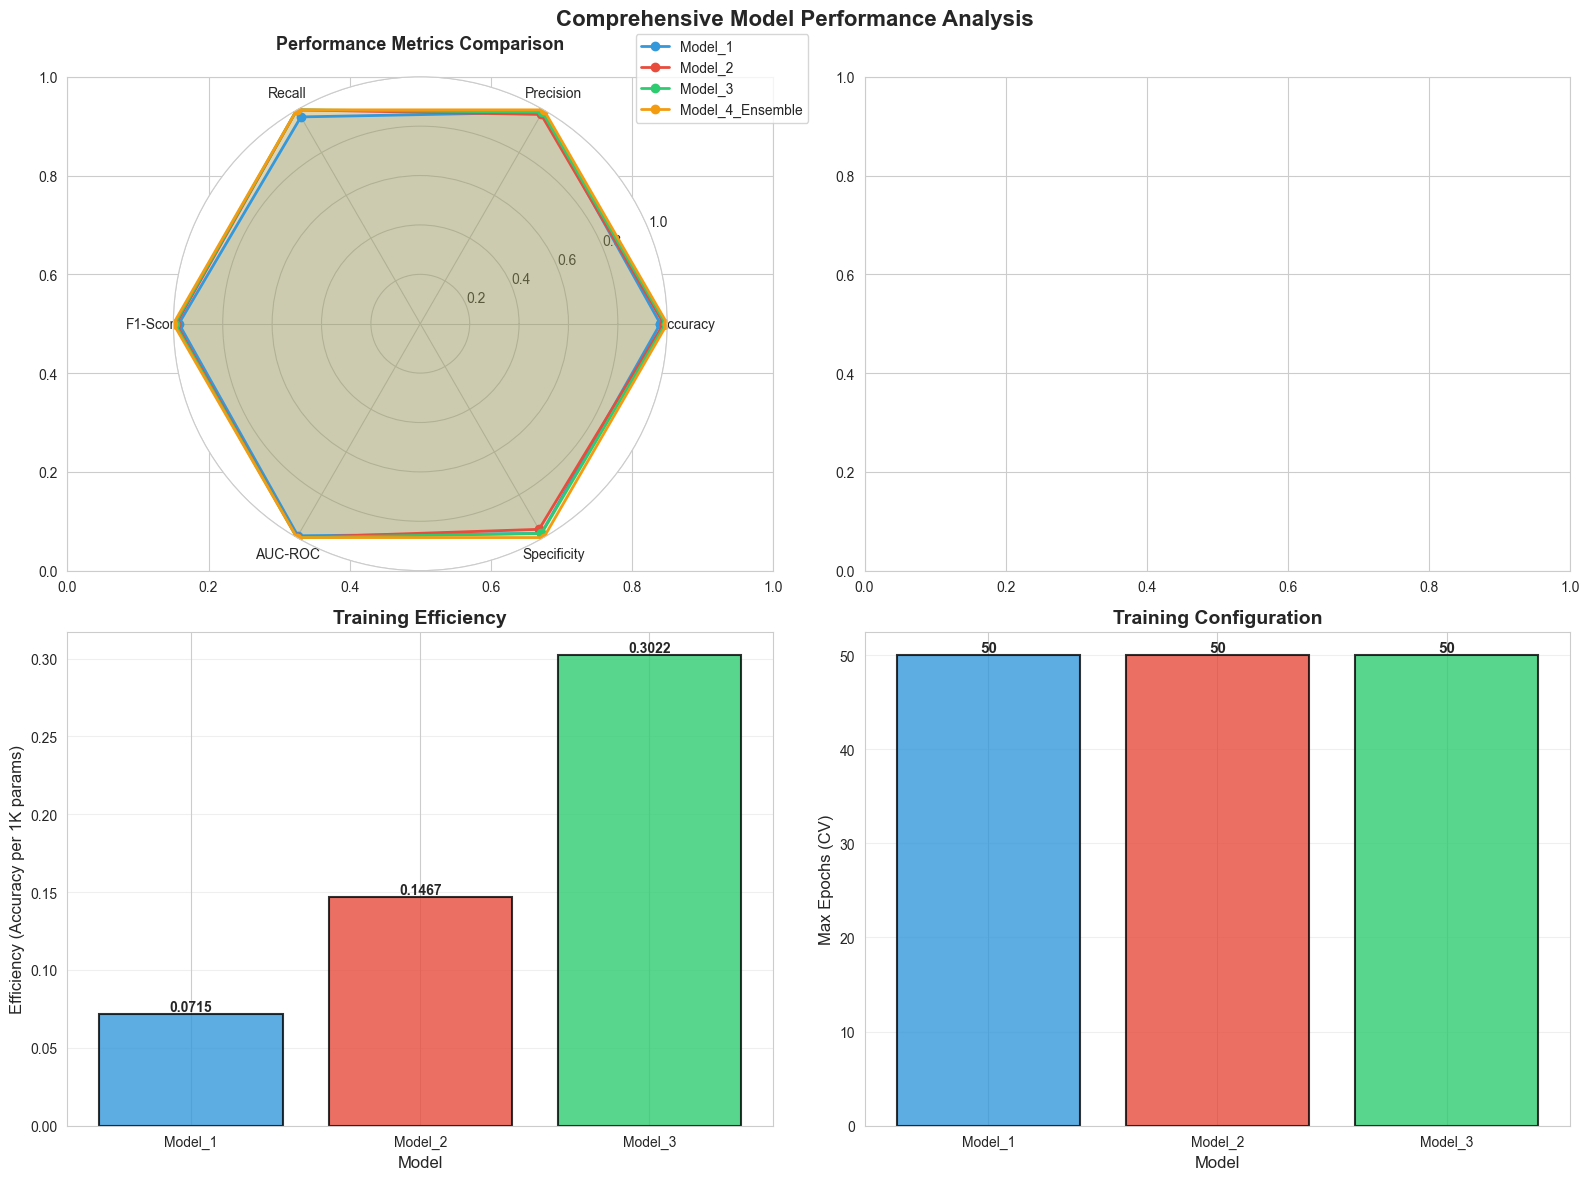

MODEL COMPLEXITY ANALYSIS (CNN Models Only)

Model_1:
  Parameters:       135,989,761
  Test Accuracy:    0.9720
  F1-Score:         0.9778
  Epochs Trained:   50
  Efficiency Score: 0.0715 (accuracy per 10M params)

Model_2:
  Parameters:       67,195,713
  Test Accuracy:    0.9860
  F1-Score:         0.9891
  Epochs Trained:   50
  Efficiency Score: 0.1467 (accuracy per 10M params)

Model_3:
  Parameters:       32,863,681
  Test Accuracy:    0.9930
  F1-Score:         0.9945
  Epochs Trained:   50
  Efficiency Score: 0.3022 (accuracy per 10M params)


In [37]:
# Prepare data for visualizations
model_names_short = [r['Model'] for r in evaluation_results]
model_accuracies = [r['Accuracy'] for r in evaluation_results]
model_f1_scores = [r['F1-Score'] for r in evaluation_results]
colors_models = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Get parameter counts (re-instantiate models to count)
model_params = []
for i in range(1, 4):
    temp_model = create_cnn_model(i)
    model_params.append(temp_model.count_params())
    del temp_model
    K.clear_session()
    gc.collect()

# Best model details
best_model_result = next(r for r in evaluation_results if r['Model'] == best_model_name)
best_sigma = next(s for s in six_sigma_results if s['Model'] == best_model_name)

# Visualize comprehensive comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comprehensive Model Performance Analysis', fontsize=16, fontweight='bold')

# Update colors for 5 models
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Spider/Radar chart data preparation
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Specificity']
num_vars = len(categories)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

# Plot 1: Radar Chart
ax = plt.subplot(2, 2, 1, projection='polar')
for idx, result in enumerate(evaluation_results):
    values = [
        result['Accuracy'],
        result['Precision'],
        result['Recall'],
        result['F1-Score'],
        result['AUC-ROC'],
        result['Specificity']
    ]
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=result['Model'], 
            color=colors[idx], markersize=6)
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_title('Performance Metrics Comparison', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

# Plot 2: Training efficiency (accuracy per 10M parameters) - CNN models only
ax = axes[1, 0]
efficiency = [acc / (params / 10000000) for acc, params in zip(model_accuracies[:3], model_params)]
bars = ax.bar(model_names_short[:3], efficiency, color=colors_models[:3], alpha=0.8, 
             edgecolor='black', linewidth=1.5)

ax.set_ylabel('Efficiency (Accuracy per 1K params)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Training Efficiency', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

# Plot 3: Epochs trained (CNN models only, ensemble has no training)
ax = axes[1, 1]
epochs_trained = [EPOCHS] * 3 # Placeholder for CV
bars = ax.bar(model_names_short[:3], epochs_trained, color=colors_models[:3], alpha=0.8, 
             edgecolor='black', linewidth=1.5)
ax.set_ylabel('Max Epochs (CV)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Training Configuration', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("="*100)
print("MODEL COMPLEXITY ANALYSIS (CNN Models Only)")
print("="*100)
for i in range(3):  # Only 3 CNN models, not ensemble
    model = model_names_short[i]
    print(f"\n{model}:")
    print(f"  Parameters:       {model_params[i]:,}")
    print(f"  Test Accuracy:    {model_accuracies[i]:.4f}")
    print(f"  F1-Score:         {model_f1_scores[i]:.4f}")
    print(f"  Epochs Trained:   {epochs_trained[i]}")
    print(f"  Efficiency Score: {efficiency[i]:.4f} (accuracy per 10M params)")




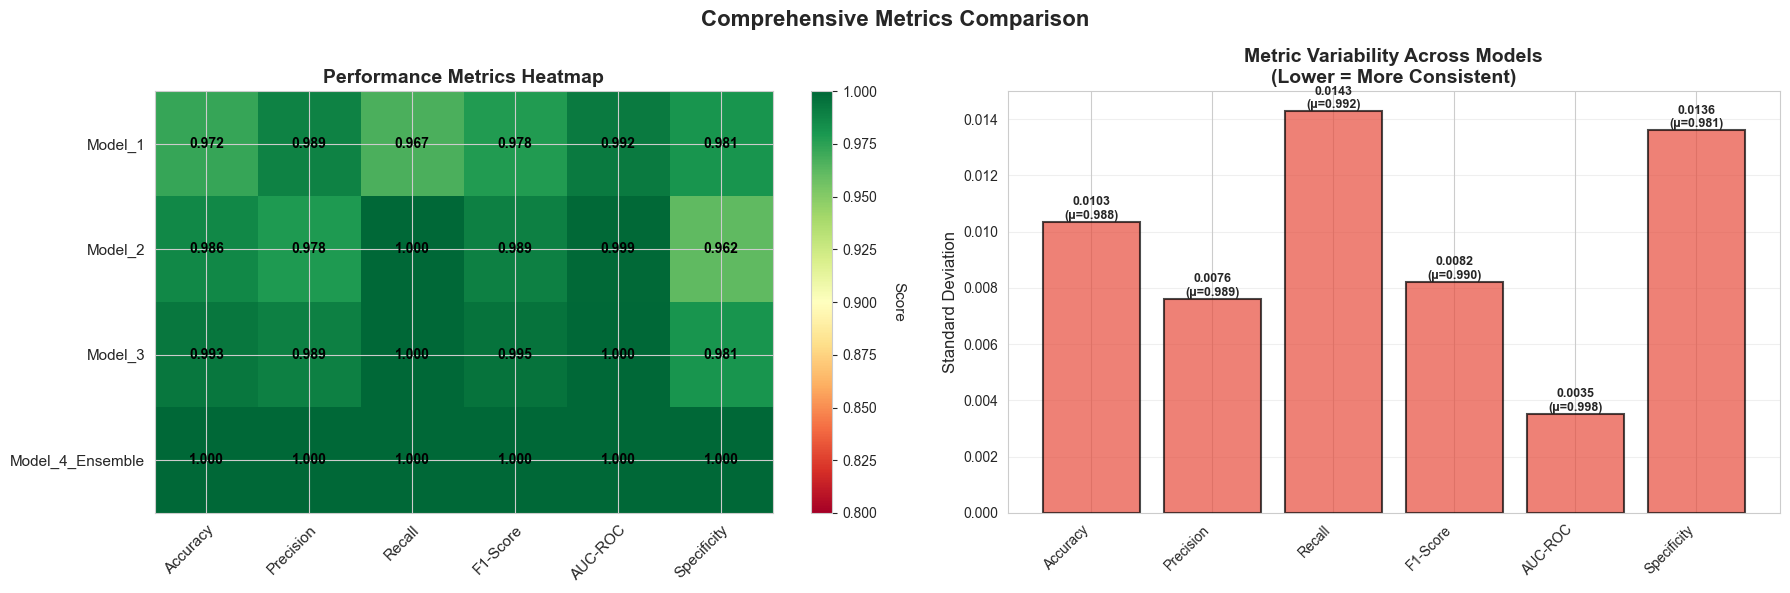

METRIC CONSISTENCY ANALYSIS

Accuracy:
  Mean:   0.9878
  Std:    0.0103
  Range:  [0.9720, 1.0000]
  Consistency: Medium

Precision:
  Mean:   0.9891
  Std:    0.0076
  Range:  [0.9785, 1.0000]
  Consistency: High

Recall:
  Mean:   0.9918
  Std:    0.0143
  Range:  [0.9670, 1.0000]
  Consistency: Medium

F1-Score:
  Mean:   0.9904
  Std:    0.0082
  Range:  [0.9778, 1.0000]
  Consistency: High

AUC-ROC:
  Mean:   0.9976
  Std:    0.0035
  Range:  [0.9915, 1.0000]
  Consistency: High

Specificity:
  Mean:   0.9808
  Std:    0.0136
  Range:  [0.9615, 1.0000]
  Consistency: Medium


In [39]:
# ============================================================================
# VISUALIZATION 3: Metrics Heatmap Comparison
# ============================================================================

# Create metrics matrix
metrics_matrix = []
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Specificity']

for result in evaluation_results:
    metrics_matrix.append([
        result['Accuracy'],
        result['Precision'],
        result['Recall'],
        result['F1-Score'],
        result['AUC-ROC'],
        result['Specificity']
    ])

metrics_matrix = np.array(metrics_matrix)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Comprehensive Metrics Comparison', fontsize=16, fontweight='bold')

# Plot 1: Heatmap
ax = axes[0]
im = ax.imshow(metrics_matrix, cmap='RdYlGn', aspect='auto', vmin=0.8, vmax=1.0)

# Set ticks
ax.set_xticks(np.arange(len(metric_names)))
ax.set_yticks(np.arange(len(model_names_short)))
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_yticklabels(model_names_short, fontsize=11)

# Rotate x labels
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Add values in cells
for i in range(len(model_names_short)):
    for j in range(len(metric_names)):
        text = ax.text(j, i, f'{metrics_matrix[i, j]:.3f}',
                      ha="center", va="center", color="black", 
                      fontsize=10, fontweight='bold')

ax.set_title('Performance Metrics Heatmap', fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Score', rotation=270, labelpad=20, fontsize=11)

# Plot 2: Metric variability across models
ax = axes[1]
metric_std = np.std(metrics_matrix, axis=0)
metric_mean = np.mean(metrics_matrix, axis=0)

x = np.arange(len(metric_names))
bars = ax.bar(x, metric_std, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Standard Deviation', fontsize=12)
ax.set_title('Metric Variability Across Models\n(Lower = More Consistent)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add values on bars
for i, (bar, std_val, mean_val) in enumerate(zip(bars, metric_std, metric_mean)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{std_val:.4f}\n(μ={mean_val:.3f})', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("="*100)
print("METRIC CONSISTENCY ANALYSIS")
print("="*100)
for i, metric in enumerate(metric_names):
    print(f"\n{metric}:")
    print(f"  Mean:   {metric_mean[i]:.4f}")
    print(f"  Std:    {metric_std[i]:.4f}")
    print(f"  Range:  [{metrics_matrix[:, i].min():.4f}, {metrics_matrix[:, i].max():.4f}]")
    print(f"  Consistency: {'High' if metric_std[i] < 0.01 else 'Medium' if metric_std[i] < 0.03 else 'Low'}")